# <font color='blue'>Data Science Academy</font>
# <font color='blue'>Análise de Dados com Linguagem Python</font>

## <font color='blue'>Projeto 6</font>
## <font color='blue'>Market Basket Analysis</font>

![title](imagens/Projeto6.png)

# O Que é MBA (Market Basket Analysis)?

A Análise de Cesta de Compras (Market Basket Analysis) é uma das principais técnicas usadas por grandes varejistas para descobrir associações entre itens. A técnica funciona procurando combinações de itens que ocorrem juntos com frequência nas transações. Em outras palavras, permite que os varejistas identifiquem as relações entre os itens que as pessoas compram.

A Análise de Cesta de Compras emprega algoritmos de regras de associação, que são amplamente utilizadas para analisar cesta de varejo ou dados de transação e têm o objetivo de identificar regras fortes descobertas em dados de transações comerciais usando medidas de interesse, com base no conceito de regras fortes.

## Pré-Requisitos

Recomendamos que você tenha concluído pelo menos os 5 primeiros capítulos do curso gratuito de <a href="https://www.datascienceacademy.com.br/course?courseid=python-fundamentos">Python Fundamentos Para Análise de Dados</a>. Recomendamos ainda o capítulo sobre Machine Learning nesse mesmo curso.

## Instalando e Carregando os Pacotes

In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python Usada Neste Jupyter Notebook:', python_version())

Versão da Linguagem Python Usada Neste Jupyter Notebook: 3.8.20


In [2]:
# Para atualizar um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install -U nome_pacote

# Para instalar a versão exata de um pacote, execute o comando abaixo no terminal ou prompt de comando:
# !pip install nome_pacote==versão_desejada

# Depois de instalar ou atualizar o pacote, reinicie o jupyter notebook.

# Instala o pacote watermark. 
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
# !pip install -q -U watermark

In [3]:
# https://pypi.org/project/efficient-apriori/
!pip install -q efficient_apriori

In [4]:
# Imports
# ============================================================
# Projeto 06 - Market Basket Analysis
# ============================================================

# Importando bibliotecas essenciais para o projeto

# NumPy: biblioteca para cálculos numéricos e manipulação de arrays
#import numpy as np  

# Pandas: biblioteca para manipulação e análise de dados em formato de tabelas (DataFrames)
#import pandas as pd  

# Matplotlib: biblioteca para criação de gráficos e visualizações
#import matplotlib.pyplot as plt  

# datetime: módulo para trabalhar com datas e horários
#from datetime import datetime  

# itertools.combinations: função que gera todas as combinações possíveis de elementos
# Exemplo: combinations([1,2,3], 2) → (1,2), (1,3), (2,3)
#from itertools import combinations  # combinações de dados  

# efficient_apriori: biblioteca especializada em mineração de regras de associação
# usada para encontrar padrões em transações (ex: compras de supermercado)
#import efficient_apriori  

# Importando diretamente a função apriori da biblioteca efficient_apriori
# O algoritmo Apriori é usado para descobrir regras de associação entre itens
# Exemplo prático: se muitos clientes compram "leite" e "pão" juntos,
# o Apriori pode sugerir que quem compra "leite" também tende a comprar "pão".
#from efficient_apriori import apriori  

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from itertools import combinations
import efficient_apriori
from efficient_apriori import apriori

In [5]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Data Science Academy" --iversions

Author: Data Science Academy

efficient_apriori: 2.0.5
matplotlib       : 3.7.5
numpy            : 1.21.0
pandas           : 1.3.3
platform         : 1.0.8



## Carregando os Dados

In [6]:
# Carrega os dados
aisle = pd.read_csv('dados/aisles.csv')
department = pd.read_csv('dados/departments.csv')
order = pd.read_csv('dados/orders.csv')
product = pd.read_csv('dados/products.csv')
order_product_prior = pd.read_csv('dados/order_products__prior.csv')
order_product_train = pd.read_csv('dados/order_products__train.csv')

## Análise Exploratória

Faz sentido calcular a correlação com colunas do tipo ID?

In [7]:
aisle.shape

(134, 2)

In [8]:
aisle.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [9]:
department.shape

(21, 2)

In [10]:
department.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [11]:
product.shape

(49688, 4)

In [12]:
product.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [13]:
order.shape

(3421083, 7)

In [14]:
order.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [15]:
order_product_prior.shape

(32434489, 4)

In [16]:
order_product_prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [17]:
order_product_train.shape

(1384617, 4)

In [18]:
order_product_train.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


Por que não usar programação e verificar o total de registros em todos os datasets de uma vez?

In [19]:
# Total de registros por dataset
# # ============================================================
# Contagem de registros em cada arquivo do projeto
# ============================================================

# Criando um array NumPy chamado count_array
# Esse array vai armazenar pares de informações: 
# (nome do arquivo, quantidade de registros dentro dele)
#count_array = np.array([
#    ['Aisles', len(aisle)],                   # Conta quantas linhas existem no dataset "aisle"
#    ['Department', len(department)],          # Conta quantas linhas existem no dataset "department"
#    ['Product', len(product)],                # Conta quantas linhas existem no dataset "product"
#    ['Order', len(order)],                    # Conta quantas linhas existem no dataset "order"
#    ['Order_Product_Prior', len(order_product_prior)],  # Conta registros do histórico de pedidos anteriores
#    ['Order_Product_Train', len(order_product_train)]   # Conta registros do conjunto de treino (pedidos atuais)
#])

# Transformando o array em um DataFrame do Pandas
# O DataFrame terá duas colunas:
# - 'Arquivo': nome do dataset
# - 'Total de Registros': quantidade de linhas em cada dataset
#count_record = pd.DataFrame(count_array, columns = ['Arquivo', 'Total de Registros'])

# Exibindo o DataFrame para visualizar a contagem de registros
# Isso ajuda a entender o tamanho de cada base de dados antes da análise
#count_record


count_array = np.array([['Aisles', len(aisle)],
                        ['Department', len(department)],
                        ['Product', len(product)],
                        ['Order', len(order)],
                        ['Order_Product_Prior', len(order_product_prior)],
                        ['Order_Product_Train', len(order_product_train)]])
count_record = pd.DataFrame(count_array, columns = ['Arquivo', 'Total de Registros'])
count_record

,Arquivo,Total de Registros
0,Aisles,134
1,Department,21
2,Product,49688
3,Order,3421083
4,Order_Product_Prior,32434489
5,Order_Product_Train,1384617


In [20]:
# Total de itens nas categorias de eval_set

## ============================================================
# Analisando a coluna 'eval_set' do DataFrame "order"
# ============================================================

# O comando abaixo conta quantas vezes cada valor aparece na coluna 'eval_set'
# Essa coluna indica em qual conjunto de dados o pedido está classificado:
# - "prior": pedidos anteriores (histórico de compras)
# - "train": pedidos usados para treinar o modelo
# - "test": pedidos usados para testar o modelo
#order['eval_set'].value_counts()

# O método .value_counts() retorna uma série com a contagem de cada categoria.
# Exemplo prático:
# Se tivermos 100 pedidos no total:
# - 70 classificados como "prior"
# - 20 classificados como "train"
# - 10 classificados como "test"
# O resultado será:
# prior    70
# train    20
# test     10

# Interpretação prática:
# Essa análise mostra a distribuição dos pedidos entre os conjuntos de dados.
# É importante porque:
# - O conjunto "prior" serve para entender o histórico de compras dos clientes.
# - O conjunto "train" é usado para ensinar o algoritmo a prever padrões.
# - O conjunto "test" é usado para avaliar se o modelo aprendeu corretamente.

order['eval_set'].value_counts()

prior    3214874
train     131209
test       75000
Name: eval_set, dtype: int64

## Limpeza dos Dados

### Verificando Valores Ausentes

In [21]:
## ============================================================
# Verificando valores ausentes no DataFrame "aisle"
# ============================================================

# O método .isna() retorna uma máscara booleana (True/False) indicando
# se cada célula do DataFrame contém um valor ausente (NaN).
# Em seguida, o método .sum() soma todos os valores True,
# resultando na quantidade total de valores ausentes por coluna.
# aisle.isna().sum()

# Exemplo prático:
# Suponha que o DataFrame "aisle" tenha 3 colunas:
# - aisle_id
# - aisle
# - department_id
# Se houver 2 valores ausentes em "aisle" e nenhum nas outras colunas,
# o resultado será:
# aisle_id        0
# aisle           2
# department_id   0

# Interpretação prática:
# Esse comando é usado para verificar a qualidade dos dados.
# Se houver valores ausentes, será necessário decidir:
# - Preencher (imputar) com algum valor padrão
# - Remover registros incompletos
# - Ou tratar de forma específica dependendo da análise
#
# Em projetos de Market Basket Analysis, dados faltantes podem atrapalhar
# a identificação correta dos produtos e categorias, por isso é essencial
# garantir que não existam NaNs nas colunas-chave.

aisle.isna().sum()

aisle_id    0
aisle       0
dtype: int64

In [22]:
department.isna().sum()

department_id    0
department       0
dtype: int64

In [23]:
order.isna().sum()

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

In [24]:
product.isna().sum()

product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

In [25]:
order_product_prior.isna().sum()

order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

In [26]:
order_product_train.isna().sum()

order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

### Feature Extraction

### Merge da Tabela order_product_prior com order, product, aisle e department

In [27]:
# Merge
## ============================================================
# Merge (junção de tabelas)
# ============================================================

# Aqui estamos unindo várias tabelas (DataFrames) em um único DataFrame chamado "order_product_prior".
# O objetivo é enriquecer os dados de pedidos anteriores com informações de produtos, departamentos e categorias.

# 1. Juntando "order_product_prior" com "order"
# - Chave de junção: 'order_id'
# - Tipo de junção: "left" (mantém todos os registros de order_product_prior e adiciona colunas de order)
#order_product_prior = order_product_prior.merge(order, on = 'order_id', how = 'left')

# 2. Juntando com "product"
# - Chave de junção: 'product_id'
# - Adiciona informações sobre os produtos comprados (nome, categoria, etc.)
#order_product_prior = order_product_prior.merge(product, on = 'product_id', how = 'left')

# 3. Juntando com "aisle"
# - Chave de junção: 'aisle_id'
# - Adiciona a informação de qual "corredor" (aisle) o produto pertence
#order_product_prior = order_product_prior.merge(aisle, on = 'aisle_id', how = 'left')

# 4. Juntando com "department"
# - Chave de junção: 'department_id'
# - Adiciona a informação de qual "departamento" o produto pertence
#order_product_prior = order_product_prior.merge(department, on = 'department_id', how = 'left')

# ============================================================
# Interpretação prática:
# ============================================================
# Após essas junções, o DataFrame "order_product_prior" passa a conter:
# - Informações do pedido (order_id, usuário, data, etc.)
# - Informações do produto (product_id, nome do produto)
# - Informações do corredor (aisle)
# - Informações do departamento (department)
#
# Isso cria uma base consolidada que permite análises completas:
# Exemplo: descobrir quais departamentos são mais comprados,
# quais corredores têm maior frequência de produtos,
# ou quais produtos aparecem juntos em pedidos anteriores.
#
# Essa etapa é essencial para o Market Basket Analysis,
# pois conecta os IDs numéricos com informações interpretáveis (nomes e categorias).

order_product_prior = order_product_prior.merge(order, on = 'order_id', how = 'left')
order_product_prior = order_product_prior.merge(product, on = 'product_id', how = 'left')
order_product_prior = order_product_prior.merge(aisle, on = 'aisle_id', how = 'left')
order_product_prior = order_product_prior.merge(department, on = 'department_id', how = 'left')

In [28]:
# ============================================================
# Visualizando os primeiros registros do DataFrame consolidado
# ============================================================

# O método .head(10) retorna as 10 primeiras linhas do DataFrame "order_product_prior".
# Isso é útil para inspecionar rapidamente como ficou a junção das tabelas
# e verificar se as colunas foram adicionadas corretamente.
#order_product_prior.head(10)

# Exemplo prático:
# Após o merge, cada linha deve conter informações como:
# - order_id: identificador do pedido
# - product_id: identificador do produto
# - product_name: nome do produto
# - aisle: corredor onde o produto está
# - department: departamento ao qual o produto pertence
# - user_id, order_number, eval_set: dados relacionados ao pedido e ao cliente

# Interpretação prática:
# Esse comando permite validar se o DataFrame está completo e coerente.
# Se aparecerem colunas duplicadas ou valores NaN inesperados,
# significa que houve algum problema na junção.
#
# Além disso, visualizar os primeiros registros ajuda a entender
# a estrutura dos dados antes de aplicar análises mais complexas,
# como regras de associação com o algoritmo Apriori.

order_product_prior.head(10)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry
5,2,17794,6,1,202279,prior,3,5,9,8.0,Carrots,83,4,fresh vegetables,produce
6,2,40141,7,1,202279,prior,3,5,9,8.0,Original Unflavored Gelatine Mix,105,13,doughs gelatins bake mixes,pantry
7,2,1819,8,1,202279,prior,3,5,9,8.0,All Natural No Stir Creamy Almond Butter,88,13,spreads,pantry
8,2,43668,9,0,202279,prior,3,5,9,8.0,Classic Blend Cole Slaw,123,4,packaged vegetables fruits,produce
9,3,33754,1,1,205970,prior,16,5,17,12.0,Total 2% with Strawberry Lowfat Greek Strained...,120,16,yogurt,dairy eggs


In [29]:
order_product_prior.isna().sum()

order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
dtype: int64

In [30]:
# ============================================================
# Verificando porcentagem de valores ausentes no DataFrame
# "order_product_prior"
# ============================================================

# O método .isnull() retorna uma máscara booleana indicando
# se cada célula contém um valor ausente (NaN).
# O método .sum() soma os valores True, resultando na quantidade
# de valores ausentes por coluna.
# Dividindo pelo total de linhas (len(order_product_prior)),
# obtemos a proporção de valores ausentes.
# Multiplicando por 100, convertemos essa proporção em porcentagem.
# ============================================================

# order_product_prior.isnull().sum() / len(order_product_prior) * 100

# Exemplo prático:
# Se uma coluna tiver 50 valores ausentes em um DataFrame com 10.000 linhas:
# (50 / 10.000) * 100 = 0.5%
# Isso significa que 0,5% dos registros dessa coluna estão incompletos.

# Interpretação prática:
# Esse comando mostra a porcentagem de valores faltantes em cada coluna.
# É uma etapa importante de validação, pois:
# - Se houver porcentagens altas, pode ser necessário tratar os dados
#   (remover colunas, preencher valores, etc.).
# - Se as porcentagens forem próximas de 0, significa que os dados estão íntegros
#   e prontos para análise.

order_product_prior.isnull().sum() / len(order_product_prior) * 100

order_id                  0.00000
product_id                0.00000
add_to_cart_order         0.00000
reordered                 0.00000
user_id                   0.00000
eval_set                  0.00000
order_number              0.00000
order_dow                 0.00000
order_hour_of_day         0.00000
days_since_prior_order    6.40697
product_name              0.00000
aisle_id                  0.00000
department_id             0.00000
aisle                     0.00000
department                0.00000
dtype: float64

Vamos manter a variável days_since_prior_order por duas razões:

1- O percentual de valores ausentes é apenas de 6.4%.

2- Não usaremos a variável com o algoritmo MBA.

### Merge da Tabela order_product_train com order, product, aisle e department

In [31]:
# ============================================================
# Merge (junção de tabelas) - Conjunto de Treino
# ============================================================

# O comando %%time é um "magic command" do Jupyter Notebook.
# Ele mede o tempo de execução da célula inteira,
# mostrando quanto tempo levou para rodar o código.
# Isso é útil para avaliar desempenho em operações pesadas,
# como merges de grandes DataFrames.
# ============================================================

# Juntando "order_product_train" com "order"
# - Chave: 'order_id'
# - Tipo de junção: left (mantém todos os registros de order_product_train)
# - Adiciona informações do pedido (usuário, número do pedido, etc.)
# order_product_train = order_product_train.merge(order, on = 'order_id', how = 'left')

# Juntando com "product"
# - Chave: 'product_id'
# - Adiciona informações sobre os produtos comprados (nome, categoria, etc.)
# order_product_train = order_product_train.merge(product, on = 'product_id', how = 'left')

# Juntando com "aisle"
# - Chave: 'aisle_id'
# - Adiciona a informação de qual corredor (aisle) o produto pertence
# order_product_train = order_product_train.merge(aisle, on = 'aisle_id', how = 'left')

# Juntando com "department"
# - Chave: 'department_id'
# - Adiciona a informação de qual departamento o produto pertence
# order_product_train = order_product_train.merge(department, on = 'department_id', how = 'left')

# ============================================================
# Interpretação prática:
# ============================================================
# Após essas junções, o DataFrame "order_product_train" passa a conter:
# - Informações do pedido (order_id, usuário, número do pedido, etc.)
# - Informações do produto (product_id, nome do produto)
# - Informações do corredor (aisle)
# - Informações do departamento (department)
#
# Isso cria uma base consolidada para o conjunto de treino,
# que será usada pelo algoritmo Apriori para aprender padrões de compra.
# ============================================================

%%time
order_product_train = order_product_train.merge(order, on = 'order_id', how = 'left')
order_product_train = order_product_train.merge(product, on = 'product_id', how = 'left')
order_product_train = order_product_train.merge(aisle, on = 'aisle_id', how = 'left')
order_product_train = order_product_train.merge(department, on = 'department_id', how = 'left')

CPU times: total: 1.33 s
Wall time: 1.31 s


In [32]:
order_product_train.head(10)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,1,49302,1,1,112108,train,4,4,10,9.0,Bulgarian Yogurt,120,16,yogurt,dairy eggs
1,1,11109,2,1,112108,train,4,4,10,9.0,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs
2,1,10246,3,0,112108,train,4,4,10,9.0,Organic Celery Hearts,83,4,fresh vegetables,produce
3,1,49683,4,0,112108,train,4,4,10,9.0,Cucumber Kirby,83,4,fresh vegetables,produce
4,1,43633,5,1,112108,train,4,4,10,9.0,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods
5,1,13176,6,0,112108,train,4,4,10,9.0,Bag of Organic Bananas,24,4,fresh fruits,produce
6,1,47209,7,0,112108,train,4,4,10,9.0,Organic Hass Avocado,24,4,fresh fruits,produce
7,1,22035,8,1,112108,train,4,4,10,9.0,Organic Whole String Cheese,21,16,packaged cheese,dairy eggs
8,36,39612,1,0,79431,train,23,6,18,30.0,Grated Pecorino Romano Cheese,2,16,specialty cheeses,dairy eggs
9,36,19660,2,1,79431,train,23,6,18,30.0,Spring Water,115,7,water seltzer sparkling water,beverages


In [33]:
order_product_train.isna().sum()

order_id                  0
product_id                0
add_to_cart_order         0
reordered                 0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_name              0
aisle_id                  0
department_id             0
aisle                     0
department                0
dtype: int64

> Vamos agrupar os dados para aplicar o algoritmo Apriori e preparar o dataset com todas as transações.

In [34]:
# ============================================================
# Agrupando produtos por pedido - Preparação para Apriori
# ============================================================

# O comando %%time mede o tempo de execução da célula inteira.
# Isso é útil porque operações de agrupamento em grandes DataFrames
# podem ser demoradas, e assim sabemos quanto tempo foi gasto.

# O método .groupby('order_id') agrupa os registros pelo identificador do pedido.
# Em seguida, selecionamos a coluna 'product_id' para cada grupo.
# Isso significa que vamos reunir todos os produtos comprados em cada pedido.

# Transformamos o resultado em um DataFrame chamado "order_grouped".
# Esse DataFrame terá como estrutura:
# - order_id: identificador do pedido
# - product_id: lista de produtos associados a esse pedido
#
# Esse formato é essencial para o algoritmo Apriori,
# pois ele precisa das transações (listas de itens comprados juntos)
# para identificar padrões e regras de associação.
# ============================================================

# order_grouped = pd.DataFrame(order_product_prior.groupby('order_id')['product_id'])

# ============================================================
# Exemplo prático:
# Se o pedido 101 tiver os produtos [Leite, Pão, Manteiga],
# o agrupamento vai gerar uma linha com order_id = 101
# e product_id = [Leite, Pão, Manteiga].
#
# Assim, cada linha representa uma "cesta de mercado",
# que será usada para descobrir quais produtos aparecem juntos
# com maior frequência.
# ============================================================

%%time
order_grouped = pd.DataFrame(order_product_prior.groupby('order_id')['product_id'])

CPU times: total: 1min
Wall time: 1min


In [35]:
order_grouped.shape

(3214874, 2)

In [36]:
# ============================================================
# Verificando o tamanho de uma lista dentro do DataFrame
# ============================================================

# O comando len(order_grouped[0]) calcula o tamanho (quantidade de elementos)
# da primeira entrada do objeto "order_grouped".
#
# Como "order_grouped" foi criado a partir de um agrupamento por 'order_id',
# cada linha representa um pedido e contém os produtos associados.
# Assim, order_grouped[0] acessa o primeiro pedido agrupado,
# e len(...) retorna quantos produtos estão presentes nesse pedido.

# len(order_grouped[0])

# ============================================================
# Exemplo prático:
# Se o primeiro pedido (order_id = 1) tiver os produtos:
# [Leite, Pão, Manteiga, Café]
# então len(order_grouped[0]) = 4
#
# Isso significa que o pedido contém 4 itens.
# ============================================================

# Interpretação prática:
# Esse comando é usado para verificar quantos produtos existem
# em uma transação específica (neste caso, a primeira).
# É uma forma de validar se o agrupamento funcionou corretamente
# e se cada pedido está representado como uma lista de produtos.

len(order_grouped[0])

3214874

In [37]:
order_grouped.head()

,0,1
0,2,0 33120 1 28985 2 9327 3 45918 4 ...
1,3,9 33754 10 24838 11 17704 12 2190...
2,4,17 46842 18 26434 19 39758 20 2776...
3,5,30 13176 31 15005 32 47329 33 2796...
4,6,56 40462 57 15873 58 41897 Name: prod...


In [38]:
# Listas
prod = []

In [39]:
# ============================================================
# Construindo lista de transações (produtos por pedido)
# ============================================================

# O comando %%time mede o tempo de execução da célula inteira.
# Isso é importante porque loops sobre grandes DataFrames podem ser demorados.

# O loop percorre cada índice da primeira coluna de "order_grouped".
# range(len(order_grouped[0])) → gera uma sequência de índices
# correspondente ao número de pedidos agrupados.

# Para cada índice "i":
# - order_grouped.iloc[i][1] acessa a segunda coluna (product_id)
#   do pedido na posição "i".
# - list(...) transforma os produtos desse pedido em uma lista.
# - prod.append(...) adiciona essa lista ao objeto "prod",
#   que será uma coleção de todas as transações (cestas de mercado).
#
# Assim, ao final do loop, "prod" conterá uma lista de listas,
# onde cada sublista representa os produtos comprados em um pedido.
# ============================================================

# for i in range(len(order_grouped[0])):
#     prod.append(list(order_grouped.iloc[i][1]))

# ============================================================
# Exemplo prático:
# Se tivermos 3 pedidos:
# Pedido 1 → [Leite, Pão]
# Pedido 2 → [Arroz, Feijão, Óleo]
# Pedido 3 → [Café]
#
# O resultado em "prod" será:
# [
#   ['Leite', 'Pão'],
#   ['Arroz', 'Feijão', 'Óleo'],
#   ['Café']
# ]
#
# Esse formato é exatamente o que o algoritmo Apriori precisa:
# uma lista de transações, cada uma contendo os itens comprados juntos.
# ============================================================

%%time
for i in range(len(order_grouped[0])):
    prod.append(list(order_grouped.iloc[i][1]))

CPU times: total: 2min 19s
Wall time: 2min 19s


In [40]:
# ============================================================
# Ajustando variável de transações
# ============================================================

# Aqui estamos apenas criando uma nova variável chamada "prod_"
# que recebe o conteúdo da lista "prod".
# Isso significa que "prod_" será uma cópia (referência) da lista original,
# contendo todas as transações (listas de produtos por pedido).

# prod_ = prod

# ============================================================
# Exemplo prático:
# Se "prod" contém:
# [
#   ['Leite', 'Pão'],
#   ['Arroz', 'Feijão', 'Óleo'],
#   ['Café']
# ]
#
# Então "prod_" também conterá exatamente a mesma estrutura.
# ============================================================

# Interpretação prática:
# Esse passo é útil para manter uma versão dos dados em outra variável,
# seja para manipulação futura ou para preservar o original.
# Assim, podemos aplicar o algoritmo Apriori em "prod_" sem risco
# de alterar a lista "prod" diretamente.

prod_ = prod

In [41]:
# ============================================================
# Ajustando variável de pedidos agrupados
# ============================================================

# Aqui estamos criando uma nova variável chamada "order_"
# que recebe o conteúdo da primeira coluna de "order_grouped".
# Como "order_grouped" foi criado a partir do agrupamento por 'order_id',
# a coluna [0] corresponde justamente aos identificadores dos pedidos.

# order_ = order_grouped[0]

# ============================================================
# Exemplo prático:
# Se "order_grouped" contém:
# order_id   product_id
# 1          [Leite, Pão]
# 2          [Arroz, Feijão]
# 3          [Café]
#
# Então "order_" será uma série com os valores:
# 1
# 2
# 3
#
# Ou seja, apenas os IDs dos pedidos.
# ============================================================

# Interpretação prática:
# Esse passo cria uma variável dedicada para armazenar
# os identificadores dos pedidos agrupados.
# Isso pode ser útil para manipulações futuras,
# como relacionar cada transação (lista de produtos) ao seu pedido original.

order_ = order_grouped[0]

In [42]:
# Prepara o dataframe
# ============================================================
# Criando DataFrame de transações
# ============================================================

# Aqui estamos criando um novo DataFrame chamado "transactions".
# Ele terá duas colunas principais:
# - "OrderID": identificador único de cada pedido (order_)
# - "Products": lista de produtos comprados nesse pedido (prod_)

# transactions = pd.DataFrame({'OrderID' : order_, 'Products' : prod_})

# ============================================================
# Exemplo prático:
# Se tivermos:
# order_ = [1, 2, 3]
# prod_ = [
#   ['Leite', 'Pão'],
#   ['Arroz', 'Feijão', 'Óleo'],
#   ['Café']
# ]
#
# O DataFrame "transactions" ficará assim:
# OrderID   Products
# 1         ['Leite', 'Pão']
# 2         ['Arroz', 'Feijão', 'Óleo']
# 3         ['Café']
# ============================================================

# Interpretação prática:
# Esse DataFrame organiza as transações de forma estruturada,
# relacionando cada pedido ao conjunto de produtos comprados.
# É a base que será usada pelo algoritmo Apriori para identificar
# padrões de compra e gerar regras de associação.

transactions = pd.DataFrame({'OrderID' : order_, 'Products' : prod_})

In [43]:
transactions.head(10)

,OrderID,Products
0,2,"[33120, 28985, 9327, 45918, 30035, 17794, 4014..."
1,3,"[33754, 24838, 17704, 21903, 17668, 46667, 174..."
2,4,"[46842, 26434, 39758, 27761, 10054, 21351, 225..."
3,5,"[13176, 15005, 47329, 27966, 23909, 48370, 132..."
4,6,"[40462, 15873, 41897]"
5,7,"[34050, 46802]"
6,8,[23423]
7,9,"[21405, 47890, 11182, 2014, 29193, 34203, 1499..."
8,10,"[24852, 4796, 31717, 47766, 4605, 1529, 21137,..."
9,11,"[30162, 27085, 5994, 1313, 31506]"


## Análise Estatística Descritiva

### 1- Qual o Número de Pedidos Mais Frequente Entre os Usuários?

In [44]:
# Agrupa os dados por usuário e número do pedido, agregando pelo maior valor
# ============================================================
# Identificando o número máximo de pedidos por usuário
# ============================================================

# Aqui estamos agrupando o DataFrame "order" pela coluna "user_id".
# Isso significa que vamos analisar os pedidos feitos por cada cliente.

# Dentro de cada grupo (cada usuário), selecionamos a coluna "order_number",
# que indica o número sequencial do pedido realizado pelo cliente.

# O método .aggregate(np.max) calcula o valor máximo de "order_number"
# para cada usuário, ou seja, o último pedido que ele realizou.
# Isso nos dá a quantidade total de pedidos feitos por cada cliente.

# O método .reset_index() reorganiza o resultado em um novo DataFrame,
# com índices numéricos padrão, facilitando a visualização.

# ord_max_count = order.groupby("user_id")['order_number'].aggregate(np.max).reset_index()

# Exibindo as primeiras linhas do resultado com .head()
# Isso mostra alguns usuários e o número máximo de pedidos que cada um realizou.
# ord_max_count.head()

# ============================================================
# Exemplo prático:
# Se o usuário 101 fez pedidos com order_number = [1, 2, 3, 4],
# o valor máximo será 4 → indicando que ele fez 4 pedidos no total.
#
# Se o usuário 202 fez pedidos com order_number = [1, 2],
# o valor máximo será 2 → indicando que ele fez 2 pedidos no total.
# ============================================================

# Interpretação prática:
# Esse comando gera uma tabela que mostra, para cada cliente,
# quantos pedidos ele já realizou. É útil para entender o comportamento
# dos usuários e identificar clientes mais ativos (com maior número de compras).

ord_max_count = order.groupby("user_id")['order_number'].aggregate(np.max).reset_index()
ord_max_count.head()

,user_id,order_number
0,1,11
1,2,15
2,3,13
3,4,6
4,5,5


In [45]:
# Faz a contagem por número de pedidos
# ============================================================
# Contando quantos usuários possuem determinado número de pedidos
# ============================================================

# O DataFrame "ord_max_count" criado anteriormente mostrava,
# para cada usuário, o número máximo de pedidos realizados
# (ou seja, quantos pedidos cada cliente fez no total).

# Agora, usamos .value_counts() sobre a coluna "order_number"
# para contar quantos usuários têm exatamente aquele número de pedidos.
# Isso gera uma distribuição da frequência de clientes
# em relação à quantidade de compras realizadas.

# ord_max_count = ord_max_count.order_number.value_counts()

# Exibindo as primeiras linhas do resultado com .head()
# Isso mostra os números de pedidos mais comuns e quantos usuários
# se enquadram em cada caso.
# ord_max_count.head()

# ============================================================
# Exemplo prático:
# Se 500 usuários fizeram exatamente 4 pedidos,
# 300 usuários fizeram exatamente 5 pedidos,
# e 100 usuários fizeram exatamente 6 pedidos,
# o resultado será:
# 4    500
# 5    300
# 6    100
#
# Isso significa que o número "4 pedidos" é o mais frequente
# entre os clientes analisados.
# ============================================================

# Interpretação prática:
# Esse comando mostra a distribuição da fidelidade dos clientes,
# indicando quantos usuários compraram apenas uma vez,
# quantos compraram várias vezes, e assim por diante.
# É uma forma de entender o engajamento e a recorrência de compras
# dentro da base de dados.

ord_max_count = ord_max_count.order_number.value_counts()
ord_max_count.head()

4    23986
5    19590
6    16165
7    13850
8    11700
Name: order_number, dtype: int64

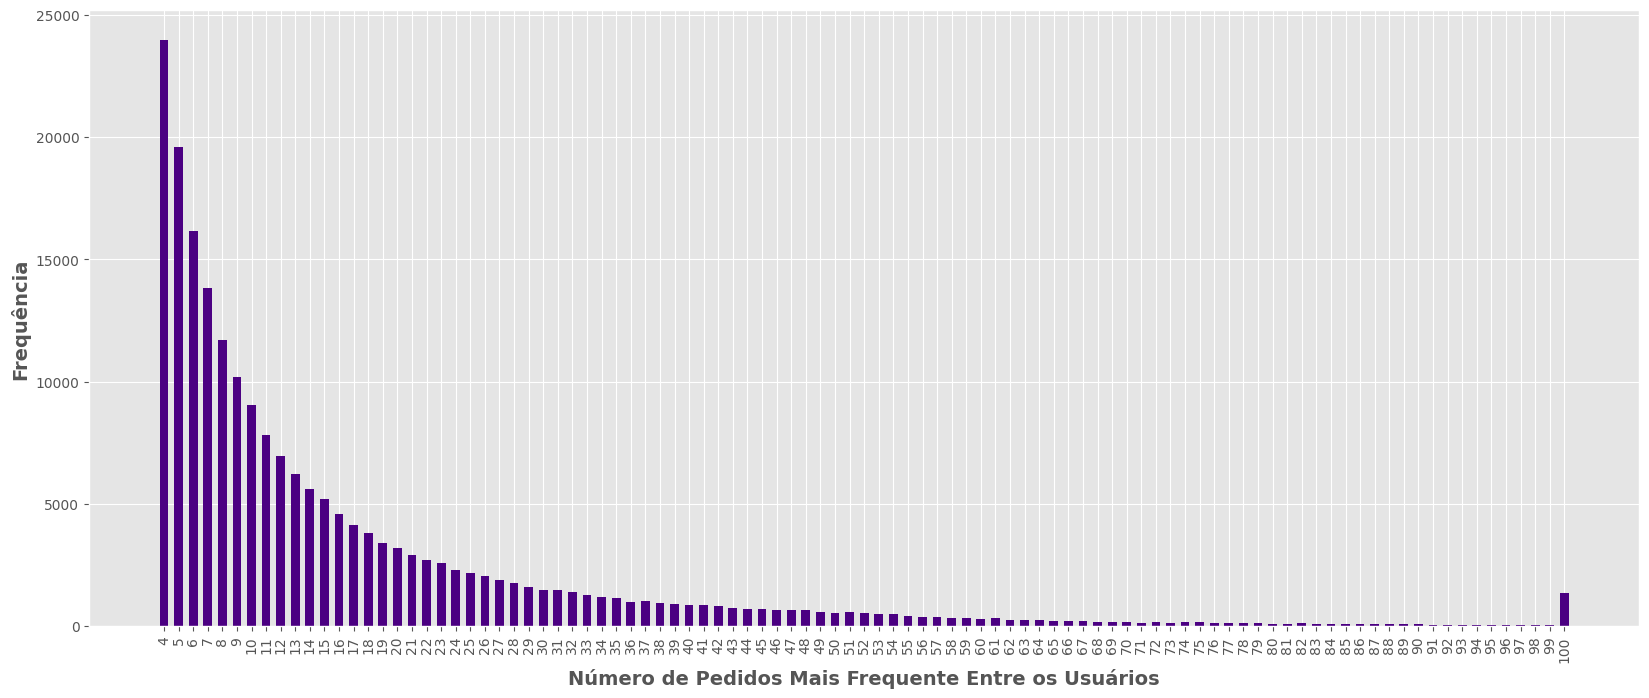

In [46]:
# Plot
# ============================================================
# Visualizando a distribuição de pedidos por usuário
# ============================================================

# Aqui estamos criando um gráfico de barras para mostrar
# quantos usuários possuem determinado número de pedidos.
# Isso ajuda a entender a frequência de compras e o engajamento dos clientes.

# plt.style.use('ggplot')
# → Define o estilo visual do gráfico como "ggplot",
#   que deixa o gráfico mais limpo e padronizado.

# plt.figure(figsize = (20,8))
# → Define o tamanho da figura (20 de largura x 8 de altura).

# plt.bar(ord_max_count.index, ord_max_count.values, color = 'indigo', width = 0.6)
# → Cria o gráfico de barras:
#   - eixo X: número de pedidos (ord_max_count.index)
#   - eixo Y: quantidade de usuários (ord_max_count.values)
#   - cor das barras: indigo
#   - largura das barras: 0.6

# plt.xticks(ord_max_count.index, rotation = 'vertical')
# → Define os rótulos do eixo X (número de pedidos) e os rotaciona na vertical
#   para facilitar a leitura.

# plt.ylabel('Frequência', fontsize = 14, fontweight = 'bold')
# → Define o rótulo do eixo Y como "Frequência",
#   com fonte maior e em negrito.

# plt.xlabel('Número de Pedidos Mais Frequente Entre os Usuários', fontsize = 14, fontweight = 'bold')
# → Define o rótulo do eixo X como "Número de Pedidos Mais Frequente Entre os Usuários",
#   também com fonte maior e em negrito.

# plt.show()
# → Exibe o gráfico na tela.
# ============================================================

# Interpretação prática:
# Esse gráfico mostra a distribuição de usuários de acordo com
# o número de pedidos realizados. É uma forma visual de identificar:
# - Quantos clientes compraram apenas uma vez
# - Quantos clientes são recorrentes (com vários pedidos)
# - Qual é o número de pedidos mais comum entre os usuários

plt.style.use('ggplot')
plt.figure(figsize = (20,8))
plt.bar(ord_max_count.index, ord_max_count.values, color = 'indigo', width = 0.6)
plt.xticks(ord_max_count.index, rotation = 'vertical')
plt.ylabel('Frequência', fontsize = 14, fontweight = 'bold')
plt.xlabel('Número de Pedidos Mais Frequente Entre os Usuários', fontsize = 14, fontweight = 'bold')
plt.show()

### 2- Qual Dia da Semana Tem o Maior Número de Pedidos?

In [47]:
# Frequências de pedidos por dia da semana (dow = day of the week)

# ============================================================
# Contando pedidos por dia da semana
# ============================================================

# Aqui estamos criando duas listas:
# - x: representa os dias da semana (0 a 6)
# - y: representa a quantidade de pedidos realizados em cada dia

# x = [0,1,2,3,4,5,6]

# Para preencher "y", usamos uma lista com o número de pedidos
# em cada dia da semana. A coluna "order_dow" indica o dia da semana
# em que o pedido foi feito (0 = domingo, 1 = segunda, ..., 6 = sábado).

# order[order['order_dow']==0].shape[0] → conta quantos pedidos foram feitos no domingo
# order[order['order_dow']==1].shape[0] → conta quantos pedidos foram feitos na segunda
# ...
# order[order['order_dow']==6].shape[0] → conta quantos pedidos foram feitos no sábado

# y = [
#     order[order['order_dow']==0].shape[0],
#     order[order['order_dow']==1].shape[0],
#     order[order['order_dow']==2].shape[0],
#     order[order['order_dow']==3].shape[0],
#     order[order['order_dow']==4].shape[0],
#     order[order['order_dow']==5].shape[0],
#     order[order['order_dow']==6].shape[0]
# ]

# ============================================================
# Exemplo prático:
# Se houver:
# - 500 pedidos no domingo
# - 700 pedidos na segunda
# - 650 pedidos na terça
# ...
# então "y" será [500, 700, 650, ...]
#
# Assim, cada posição da lista "y" corresponde ao número de pedidos
# em um dia específico da semana.
# ============================================================

# Interpretação prática:
# Esse passo prepara os dados para criar um gráfico ou análise
# mostrando em quais dias da semana os clientes mais compram.
# É útil para identificar padrões de comportamento,
# como maior volume de compras em finais de semana ou dias úteis.

x = [0,1,2,3,4,5,6]
y = [order[order['order_dow']==0].shape[0],
     order[order['order_dow']==1].shape[0],
     order[order['order_dow']==2].shape[0],
     order[order['order_dow']==3].shape[0],
     order[order['order_dow']==4].shape[0],
     order[order['order_dow']==5].shape[0],
     order[order['order_dow']==6].shape[0]]

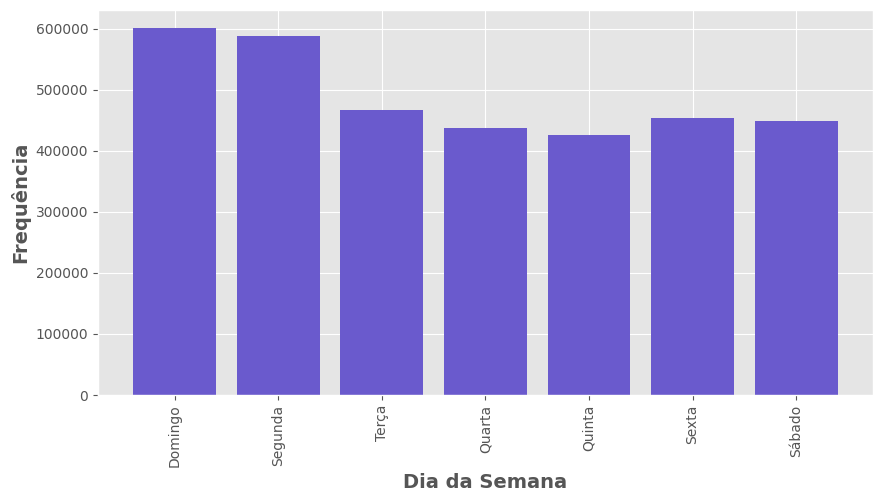

In [48]:
# Plot
plt.figure(figsize = (10,5))
plt.bar(x,y, color = 'slateblue')
plt.xlabel('Dia da Semana', fontsize = 14, fontweight = 'bold')
plt.ylabel('Frequência', fontsize = 14, fontweight = 'bold')
plt.xticks(x,['Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado'], rotation = 'vertical')
plt.show()

### 3- Qual Hora do Dia Tem o Maior Número de Pedidos?

In [49]:
# Frequências de pedidos pela hora do dia
# ============================================================
# Contando pedidos por hora do dia
# ============================================================

# Aqui estamos criando duas listas:
# - x: representa as horas do dia (0 a 23)
# - y: representa a quantidade de pedidos realizados em cada hora

# x = list(range(0,24))
# → Cria uma lista com os números de 0 até 23,
#   correspondendo às 24 horas do dia.

# y = []
# → Inicializa uma lista vazia que será preenchida com os totais de pedidos.

# O loop percorre todas as 24 horas:
# for i in range(24):
#     y.append(order[order['order_hour_of_day']==i].shape[0])

# Explicação do loop:
# - order['order_hour_of_day']==i → seleciona todos os pedidos feitos na hora "i".
# - .shape[0] → retorna o número de linhas (quantidade de pedidos).
# - y.append(...) → adiciona esse número à lista "y".

# Ao final, "y" conterá 24 valores,
# cada um representando o número de pedidos feitos em cada hora do dia.
# ============================================================

# Exemplo prático:
# Se houver:
# - 200 pedidos às 8h
# - 500 pedidos às 15h
# - 100 pedidos às 23h
# então "y" terá valores como [..., 200, ..., 500, ..., 100].
#
# Assim, cada posição da lista "y" corresponde ao volume de pedidos
# em uma hora específica.
# ============================================================

# Interpretação prática:
# Esse passo prepara os dados para criar um gráfico ou análise
# mostrando em quais horários os clientes mais compram.
# É útil para identificar padrões de comportamento,
# como picos de compras pela manhã, tarde ou noite.

x = list(range(0,24))
y = []
for i in range(24):
    y.append(order[order['order_hour_of_day']==i].shape[0])

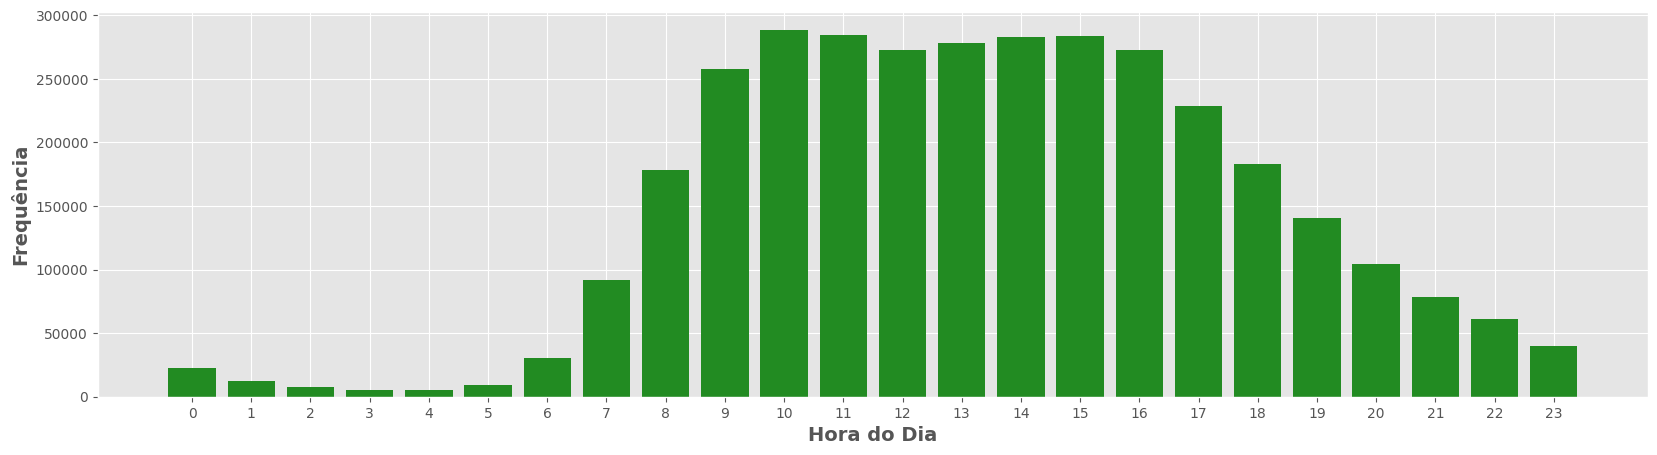

In [50]:
# Plot
plt.figure(figsize = (20,5))
plt.bar(x,y,color = 'forestgreen')
plt.xticks(np.arange(0,24,1))
plt.xlabel('Hora do Dia', fontsize = 14, fontweight = 'bold')
plt.ylabel('Frequência', fontsize = 14, fontweight = 'bold')
plt.show()

### 4- Qual Departamento Tem o Maior Número de Pedidos?

In [51]:
# Contagem de pedidos por departamento
# ============================================================
# Contando produtos por departamento
# ============================================================

# Aqui estamos utilizando o método .value_counts()
# para contar quantas vezes cada valor aparece na coluna "department"
# do DataFrame "order_product_prior".

# Isso significa que vamos obter a quantidade de produtos
# comprados em cada departamento, ordenados de forma decrescente
# (do mais frequente para o menos frequente).

# dept_cnt = order_product_prior['department'].value_counts()

# ============================================================
# Exemplo prático:
# Se a coluna "department" tiver os seguintes valores:
# ['Bebidas', 'Padaria', 'Padaria', 'Frutas', 'Padaria', 'Frutas']
#
# O resultado será:
# Padaria    3
# Frutas     2
# Bebidas    1
#
# Isso mostra que o departamento "Padaria" foi o mais comprado.
# ============================================================

# Interpretação prática:
# Esse comando ajuda a identificar quais departamentos
# concentram mais compras dentro da base de dados.
# É útil para entender o comportamento dos clientes,
# como quais áreas da loja são mais populares
# e podem gerar maior receita.

dept_cnt = order_product_prior['department'].value_counts()

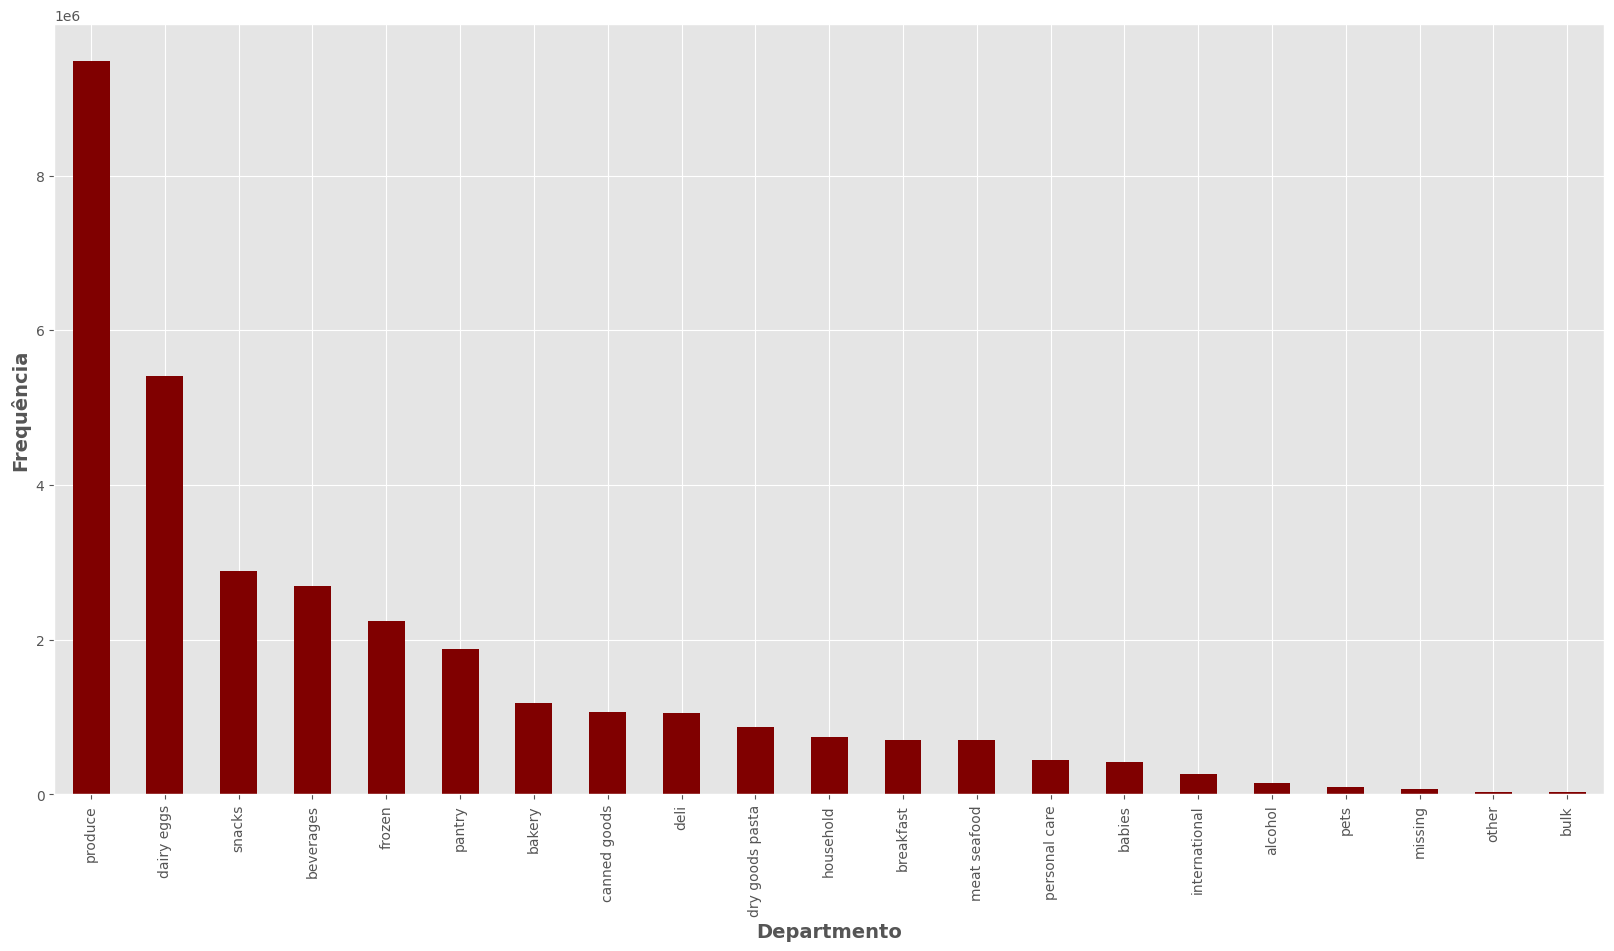

In [52]:
# Plot
fig = plt.figure(figsize = (20,10))
dept_cnt.plot(kind = "bar", color = 'maroon')
plt.xticks(rotation = 90)
plt.xlabel('Departmento', fontsize = 14, fontweight = 'bold')
plt.ylabel('Frequência', fontsize = 14, fontweight = 'bold')
plt.show()

### 5- Quais os 20 Principais Corredores Por Frequência de Pedidos?

In [53]:
# Os 20 principais corredores e sua frequência de pedidos
# ============================================================
# Contando produtos por corredor (aisle)
# ============================================================

# Aqui estamos utilizando o método .value_counts()
# para contar quantas vezes cada valor aparece na coluna "aisle"
# do DataFrame "order_product_prior".

# Isso significa que vamos obter a quantidade de produtos
# comprados em cada corredor da loja, ordenados de forma decrescente
# (do mais frequente para o menos frequente).

# aisle_cnt = order_product_prior['aisle'].value_counts()

# ============================================================
# Exemplo prático:
# Se a coluna "aisle" tiver os seguintes valores:
# ['Bebidas', 'Padaria', 'Padaria', 'Frutas', 'Padaria', 'Frutas']
#
# O resultado será:
# Padaria    3
# Frutas     2
# Bebidas    1
#
# Isso mostra que o corredor "Padaria" foi o mais comprado.
# ============================================================

# Interpretação prática:
# Esse comando ajuda a identificar quais corredores da loja
# concentram mais compras dentro da base de dados.
# É útil para entender o comportamento dos clientes,
# como quais áreas físicas da loja são mais populares
# e podem ser estratégicas para promoções ou organização.

aisle_cnt = order_product_prior['aisle'].value_counts()

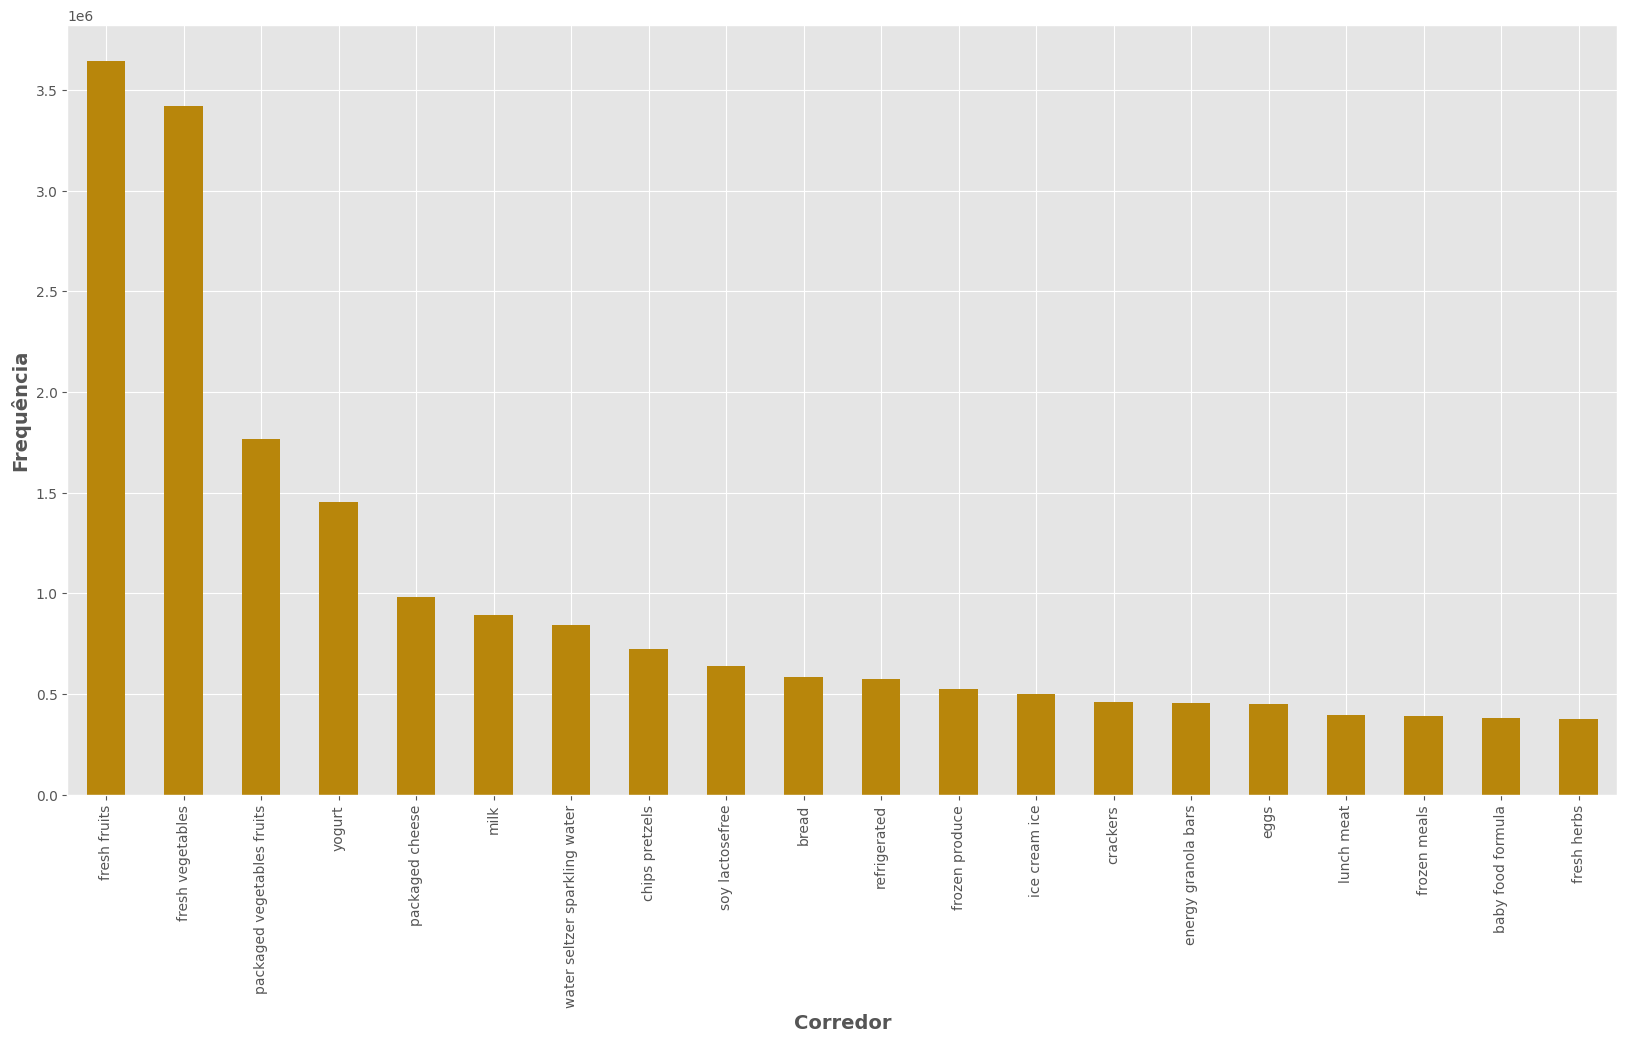

In [54]:
# Plot
fig = plt.figure(figsize = (20,10))
aisle_cnt[0:20].plot(kind = "bar", color = 'darkgoldenrod')
plt.xticks(rotation = 90)
plt.xlabel('Corredor', fontsize = 14, fontweight = 'bold')
plt.ylabel('Frequência', fontsize = 14, fontweight = 'bold')
plt.show()

### 6- Quais os 20 Principais Produtos Por Frequência de Pedidos?

In [55]:
# Os 20 principais produtos por frequência de pedido
# ============================================================
# Contando produtos mais comprados
# ============================================================

# Aqui estamos utilizando o método .value_counts()
# para contar quantas vezes cada valor aparece na coluna "product_name"
# do DataFrame "order_product_prior".

# Isso significa que vamos obter a quantidade de vezes
# que cada produto foi comprado, ordenados de forma decrescente
# (do mais comprado para o menos comprado).

# prod_cnt = order_product_prior['product_name'].value_counts()

# ============================================================
# Exemplo prático:
# Se a coluna "product_name" tiver os seguintes valores:
# ['Leite', 'Pão', 'Pão', 'Arroz', 'Leite', 'Leite']
#
# O resultado será:
# Leite    3
# Pão      2
# Arroz    1
#
# Isso mostra que "Leite" foi o produto mais comprado.
# ============================================================

# Interpretação prática:
# Esse comando ajuda a identificar quais produtos
# são os mais populares entre os clientes.
# É uma análise fundamental para entender o comportamento de compra,
# planejar estoque e até sugerir promoções baseadas nos itens mais vendidos.

prod_cnt = order_product_prior['product_name'].value_counts()

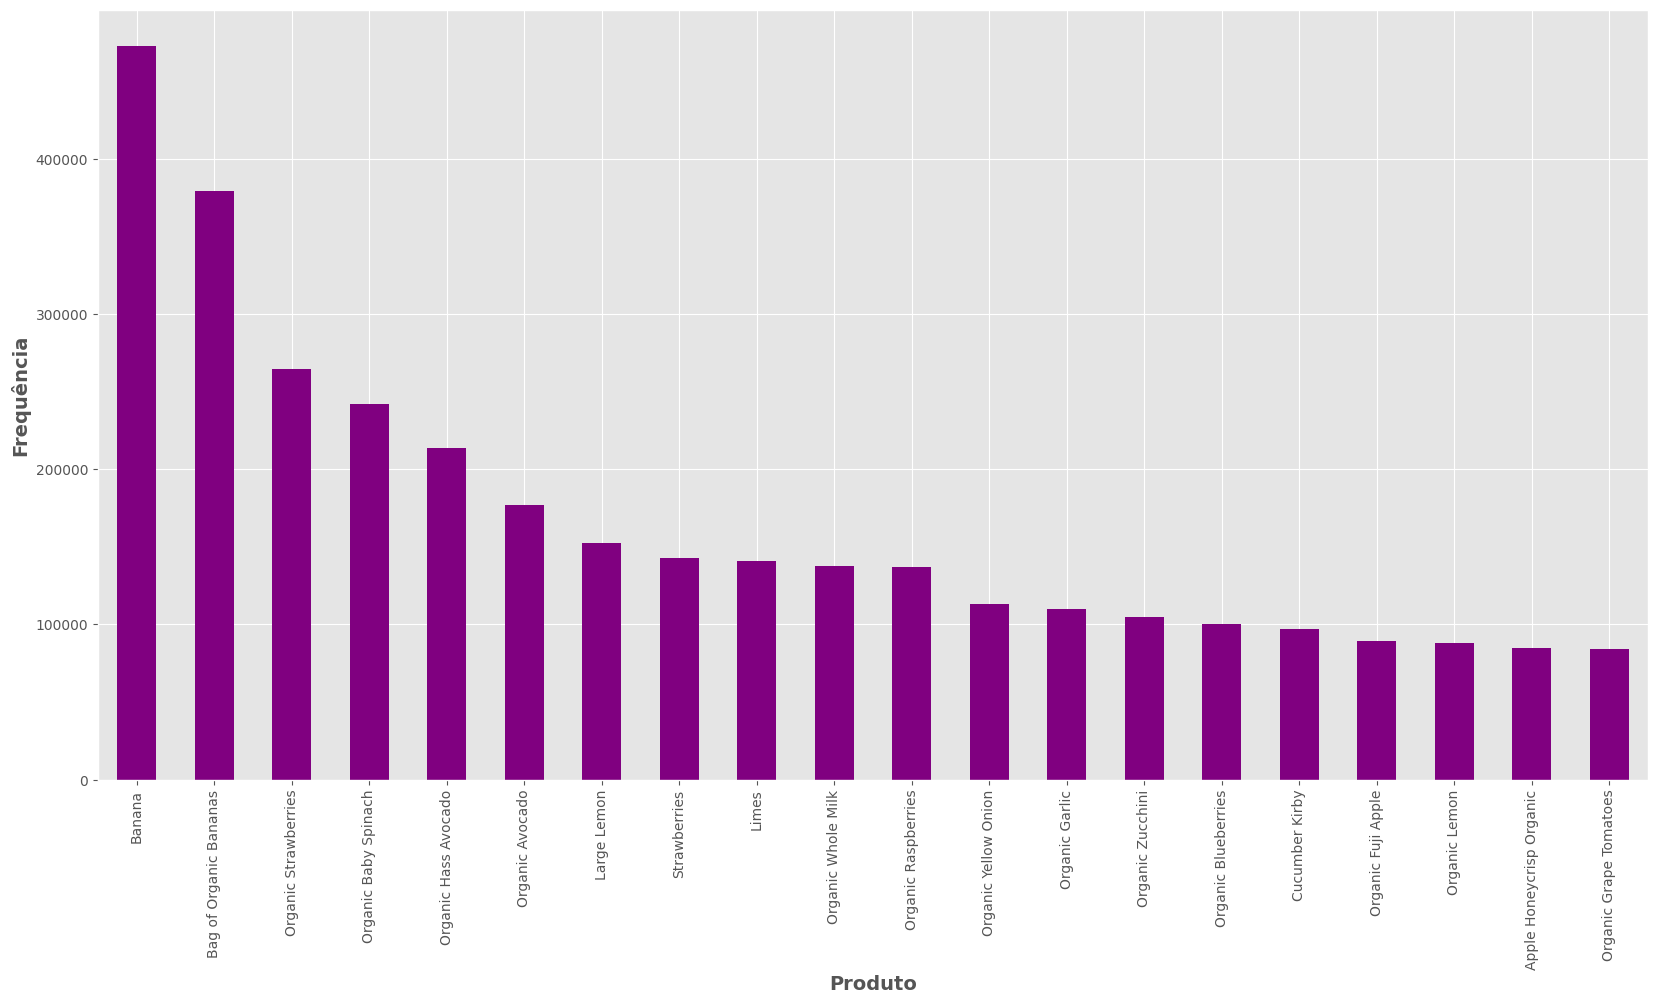

In [56]:
# Plot
fig = plt.figure(figsize = (20,10))
prod_cnt[0:20].plot(kind = "bar", color = 'purple')
plt.xticks(rotation = 90)
plt.xlabel('Produto', fontsize = 14, fontweight = 'bold')
plt.ylabel('Frequência', fontsize = 14, fontweight = 'bold')
plt.show()

### 7- Análise de Novos Pedidos Semelhantes a Pedidos Anteriores (reorder)

In [57]:
# ============================================================
# Calculando estatísticas de reordenação por produto
# ============================================================

# O comando %%time mede o tempo de execução da célula inteira,
# útil porque operações de agrupamento e agregação em grandes DataFrames
# podem ser demoradas.

# Agrupamos o DataFrame "order_product_prior" pela coluna "product_name".
# Dentro de cada grupo (cada produto), selecionamos a coluna "reordered",
# que indica se o produto foi recomprado (1) ou não (0).

# .agg(['count', 'sum']) → aplica duas funções de agregação:
# - 'count': número total de vezes que o produto aparece nos pedidos
# - 'sum': número total de vezes que o produto foi recomprado (reordered = 1)

# .rename(columns = {'count':'total','sum':'reorders'})
# → renomeia as colunas para nomes mais claros:
#   - "total" = total de compras do produto
#   - "reorders" = total de recompras do produto

# .sort_values('total', ascending = False)
# → ordena os produtos pelo número total de compras (do mais comprado para o menos comprado).

# .reset_index()
# → reorganiza o índice para facilitar a visualização.

# temp_df = order_product_prior.groupby("product_name")["reordered"].agg(['count', 'sum']).rename(columns = {'count':'total','sum':'reorders'})
# temp_df = temp_df.sort_values('total', ascending = False).reset_index()

# ============================================================
# Exemplo prático:
# Se o produto "Leite" aparece 100 vezes e foi recomprado 60 vezes,
# teremos:
# product_name | total | reorders
# Leite        | 100   | 60
#
# Se "Pão" aparece 80 vezes e foi recomprado 50 vezes:
# Pão          | 80    | 50
# ============================================================

# Interpretação prática:
# Esse comando gera uma tabela que mostra:
# - Quantas vezes cada produto foi comprado
# - Quantas vezes cada produto foi recomprado
#
# É uma análise fundamental para identificar produtos populares
# e também aqueles com maior fidelidade (alta taxa de recompras).


%%time
temp_df = order_product_prior.groupby("product_name")["reordered"].agg(['count', 'sum']).rename(columns = {'count':'total','sum':'reorders'})
temp_df = temp_df.sort_values('total', ascending = False).reset_index()


CPU times: total: 4.92 s
Wall time: 5 s


In [58]:
# Prepara as listas
# ============================================================
# Selecionando os Top 20 produtos mais comprados
# ============================================================

# Aqui estamos criando três listas a partir do DataFrame "temp_df":
# - labels: nomes dos 20 produtos mais comprados
# - reorder: quantidade de recompras (reorders) desses produtos
# - total: quantidade total de compras desses produtos

# labels = list(temp_df.product_name[0:20])
# → Pega os nomes dos 20 primeiros produtos (mais comprados).

# reorder = list(temp_df.reorders[0:20])
# → Pega o número de recompras desses 20 produtos.

# total = list(temp_df.total[0:20])
# → Pega o número total de compras desses 20 produtos.

# ============================================================
# Exemplo prático:
# Se os produtos mais comprados forem:
# 1. Banana (total=1000, reorders=700)
# 2. Leite (total=900, reorders=500)
# ...
# então:
# labels = ['Banana', 'Leite', ...]
# reorder = [700, 500, ...]
# total = [1000, 900, ...]
# ============================================================

# Interpretação prática:
# Essas listas são úteis para criar gráficos comparativos,
# como barras ou pizza, mostrando os produtos mais populares
# e também sua taxa de recompra.
# Isso ajuda a identificar não apenas os itens mais vendidos,
# mas também aqueles que os clientes tendem a comprar repetidamente.

labels = list(temp_df.product_name[0:20])
reorder = list(temp_df.reorders[0:20])
total = list(temp_df.total[0:20])    

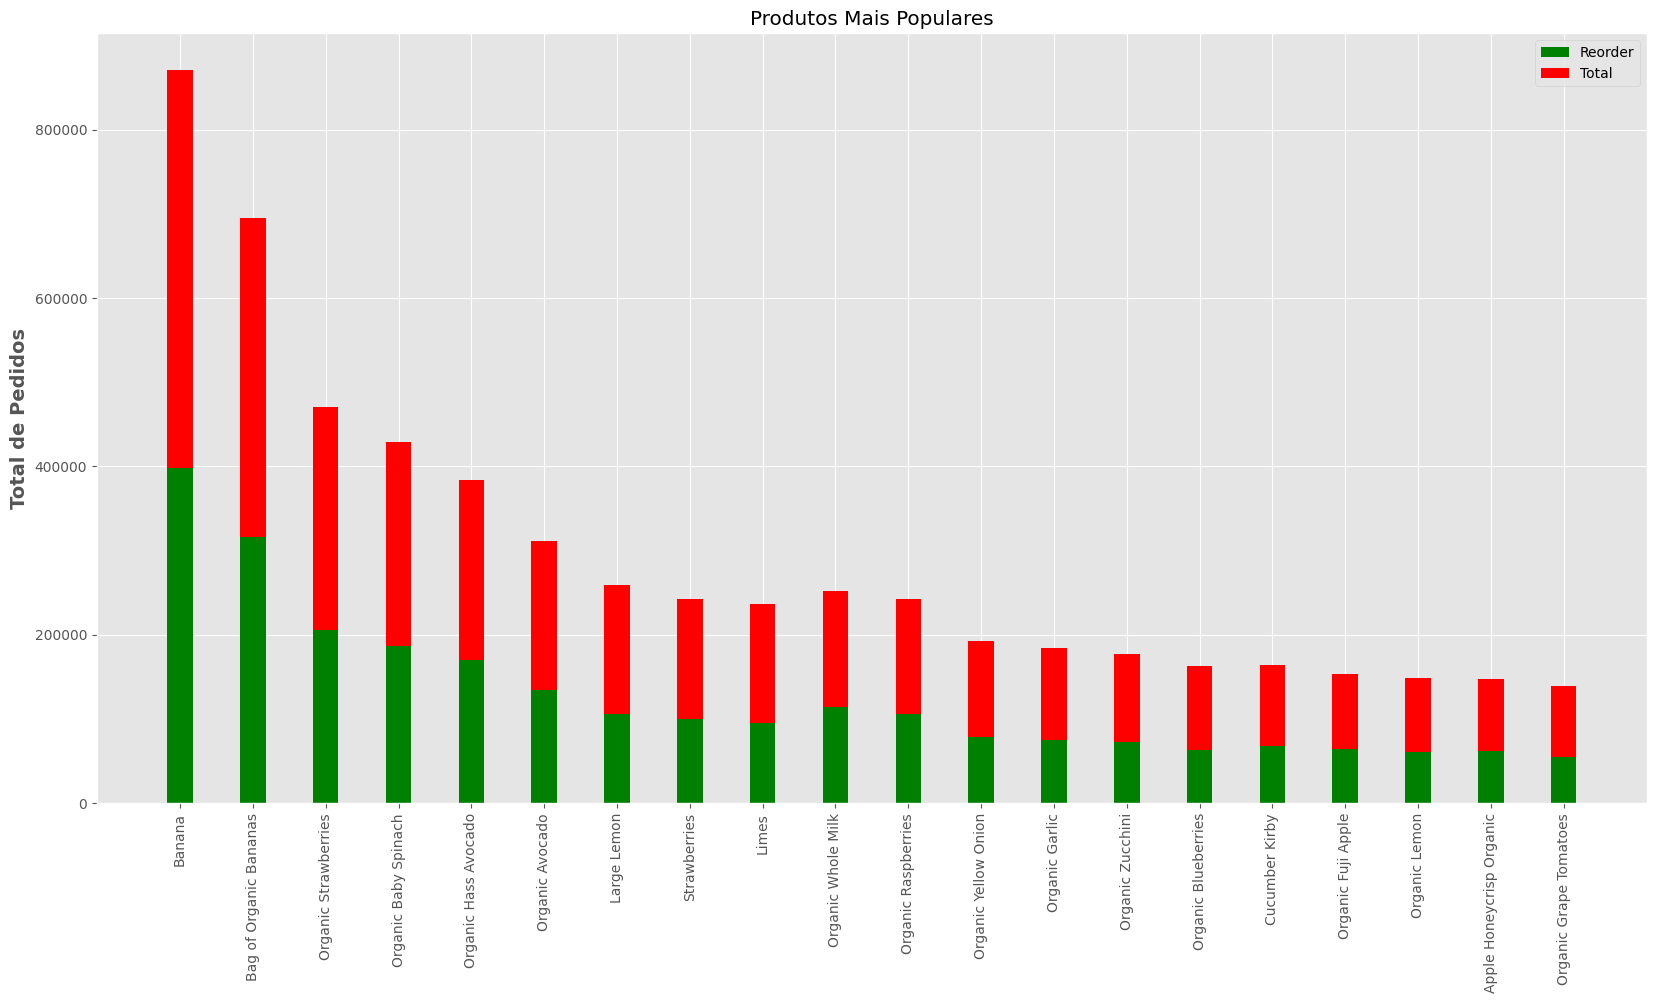

In [59]:
# Plot  
width = 0.35 
fig, ax = plt.subplots(figsize = (20,10))
ax.bar(labels, reorder, width, label = 'Reorder', color = 'green')
ax.bar(labels, total, width, bottom = reorder, label = 'Total', color = 'red')
ax.set_ylabel('Total de Pedidos', fontsize = 14, fontweight = 'bold')
ax.legend()
ax.set_title("Produtos Mais Populares")
plt.xticks(rotation = 90)
plt.show()

### 7- Análise de Reorder Por Departamento ao Longo do Tempo

In [60]:
# Agrupando os dados por departamento e reorder
# ============================================================
# Calculando taxa média de recompra por departamento
# ============================================================

# Aqui estamos agrupando o DataFrame "order_product_prior"
# pela coluna "department".
# Dentro de cada grupo (cada departamento), selecionamos a coluna "reordered",
# que indica se o produto foi recomprado (1) ou não (0).

# .aggregate("mean") → calcula a média da coluna "reordered"
# para cada departamento.
# Como "reordered" é binário (0 ou 1), a média representa
# a proporção de vezes que os produtos daquele departamento
# foram recomprados.

# .reset_index() → reorganiza o resultado em um novo DataFrame,
# com índices numéricos padrão, facilitando a visualização.

# grouped_df = order_product_prior.groupby(["department"])["reordered"].aggregate("mean").reset_index()
# grouped_df.head()

# ============================================================
# Exemplo prático:
# Se no departamento "Frutas" houver 100 compras e 60 delas forem recompras,
# a média será 0.60 → indicando que 60% das compras de frutas são recompras.
#
# Se no departamento "Padaria" houver 200 compras e 150 forem recompras,
# a média será 0.75 → indicando que 75% das compras de padaria são recompras.
# ============================================================

# Interpretação prática:
# Esse comando gera uma tabela que mostra, para cada departamento,
# a taxa média de recompra dos produtos.
# É uma análise fundamental para entender a fidelidade dos clientes
# em diferentes áreas da loja.
# Departamentos com valores mais altos indicam produtos
# que os clientes tendem a comprar repetidamente.

grouped_df = order_product_prior.groupby(["department"])["reordered"].aggregate("mean").reset_index()
grouped_df.head()

,department,reordered
0,alcohol,0.569924
1,babies,0.578971
2,bakery,0.628141
3,beverages,0.653460
4,breakfast,0.560922


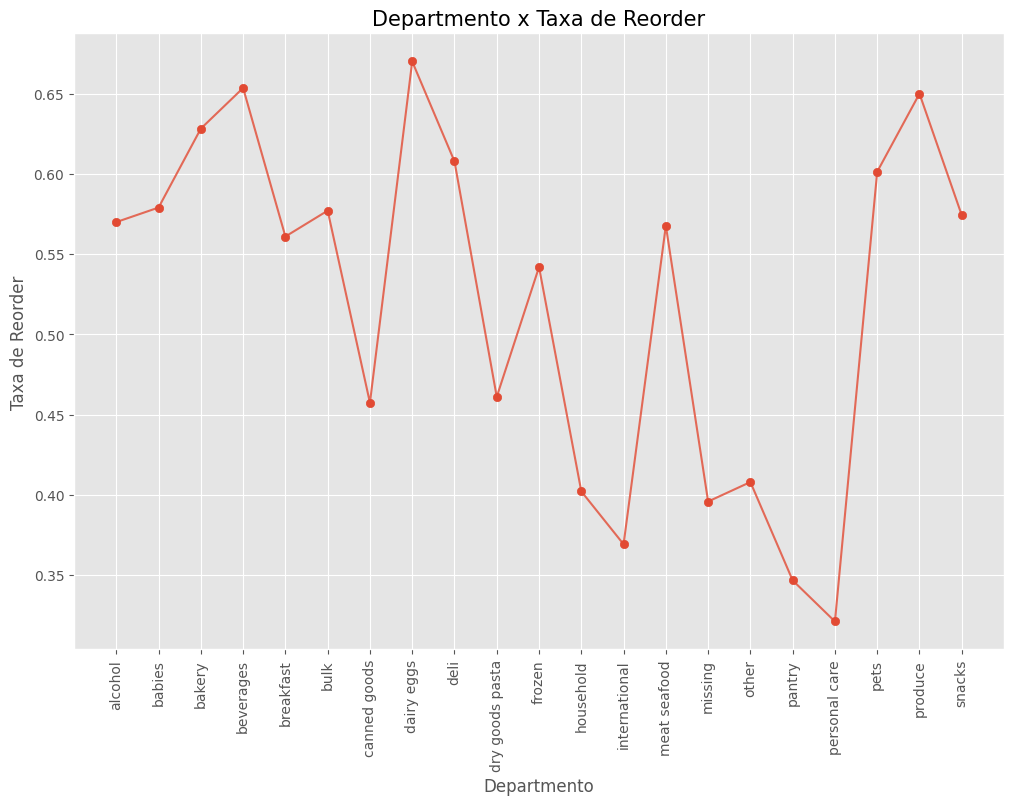

In [61]:
# Plot
plt.figure(figsize = (12,8))
plt.plot(list(grouped_df['department']), grouped_df['reordered'].values, alpha=0.8)
plt.scatter(list(grouped_df['department']), grouped_df['reordered'].values)
plt.ylabel('Taxa de Reorder', fontsize = 12)
plt.xlabel('Departmento', fontsize = 12)
plt.title("Departmento x Taxa de Reorder", fontsize = 15)
plt.xticks(rotation = 'vertical')
plt.show()

### 8- Análise de Reorder e Pedidos

In [62]:
# ============================================================
# Calculando estatísticas de reordenação por departamento
# ============================================================

# O comando %%time mede o tempo de execução da célula inteira,
# útil porque operações de agrupamento e agregação em grandes DataFrames
# podem ser demoradas.

# Agrupamos o DataFrame "order_product_prior" pela coluna "department".
# Dentro de cada grupo (cada departamento), selecionamos a coluna "reordered",
# que indica se o produto foi recomprado (1) ou não (0).

# .agg(['count', 'sum']) → aplica duas funções de agregação:
# - 'count': número total de vezes que os produtos do departamento aparecem nos pedidos
# - 'sum': número total de vezes que os produtos foram recomprados (reordered = 1)

# .rename(columns = {'count':'total','sum':'reorders'})
# → renomeia as colunas para nomes mais claros:
#   - "total" = total de compras do departamento
#   - "reorders" = total de recompras do departamento

# .sort_values('total', ascending = False)
# → ordena os departamentos pelo número total de compras (do mais comprado para o menos comprado).

# .reset_index()
# → reorganiza o índice para facilitar a visualização.

# temp_df = order_product_prior.groupby("department")["reordered"].agg(['count', 'sum']).rename(columns = {'count':'total','sum':'reorders'})
# temp_df = temp_df.sort_values('total', ascending = False).reset_index()

# ============================================================
# Exemplo prático:
# Se no departamento "Frutas" houver 100 compras e 60 delas forem recompras,
# teremos:
# department | total | reorders
# Frutas     | 100   | 60
#
# Se no departamento "Padaria" houver 200 compras e 150 forem recompras:
# Padaria    | 200   | 150
# ============================================================

# Interpretação prática:
# Esse comando gera uma tabela que mostra:
# - Quantas vezes os produtos de cada departamento foram comprados
# - Quantas vezes foram recomprados
#
# É uma análise fundamental para identificar não apenas os departamentos
# mais populares, mas também aqueles com maior fidelidade dos clientes.

%%time
temp_df = order_product_prior.groupby("department")["reordered"].agg(['count', 'sum']).rename(columns = {'count':'total','sum':'reorders'})
temp_df = temp_df.sort_values('total', ascending = False).reset_index()


CPU times: total: 1.88 s
Wall time: 1.89 s


In [63]:
temp_df.head()

,department,total,reorders
0,produce,9479291,6160710
1,dairy eggs,5414016,3627221
2,snacks,2887550,1657973
3,beverages,2690129,1757892
4,frozen,2236432,1211890


In [64]:
# Listas
# ============================================================
# Selecionando os Top 20 departamentos mais comprados
# ============================================================

# Aqui estamos criando três listas a partir do DataFrame "temp_df":
# - labels: nomes dos 20 departamentos mais comprados
# - reorder: quantidade de recompras (reorders) desses departamentos
# - total: quantidade total de compras desses departamentos

# labels = list(temp_df.department[0:20])
# → Pega os nomes dos 20 primeiros departamentos (mais comprados).

# reorder = list(temp_df.reorders[0:20])
# → Pega o número de recompras desses 20 departamentos.

# total = list(temp_df.total[0:20])
# → Pega o número total de compras desses 20 departamentos.

# ============================================================
# Exemplo prático:
# Se os departamentos mais comprados forem:
# 1. Padaria (total=5000, reorders=3500)
# 2. Frutas (total=4500, reorders=3000)
# ...
# então:
# labels = ['Padaria', 'Frutas', ...]
# reorder = [3500, 3000, ...]
# total = [5000, 4500, ...]
# ============================================================

# Interpretação prática:
# Essas listas são úteis para criar gráficos comparativos,
# como barras ou pizza, mostrando os departamentos mais populares
# e também sua taxa de recompra.
# Isso ajuda a identificar não apenas os departamentos mais vendidos,
# mas também aqueles que os clientes tendem a comprar repetidamente.

labels = list(temp_df.department[0:20])
reorder = list(temp_df.reorders[0:20])
total = list(temp_df.total[0:20])

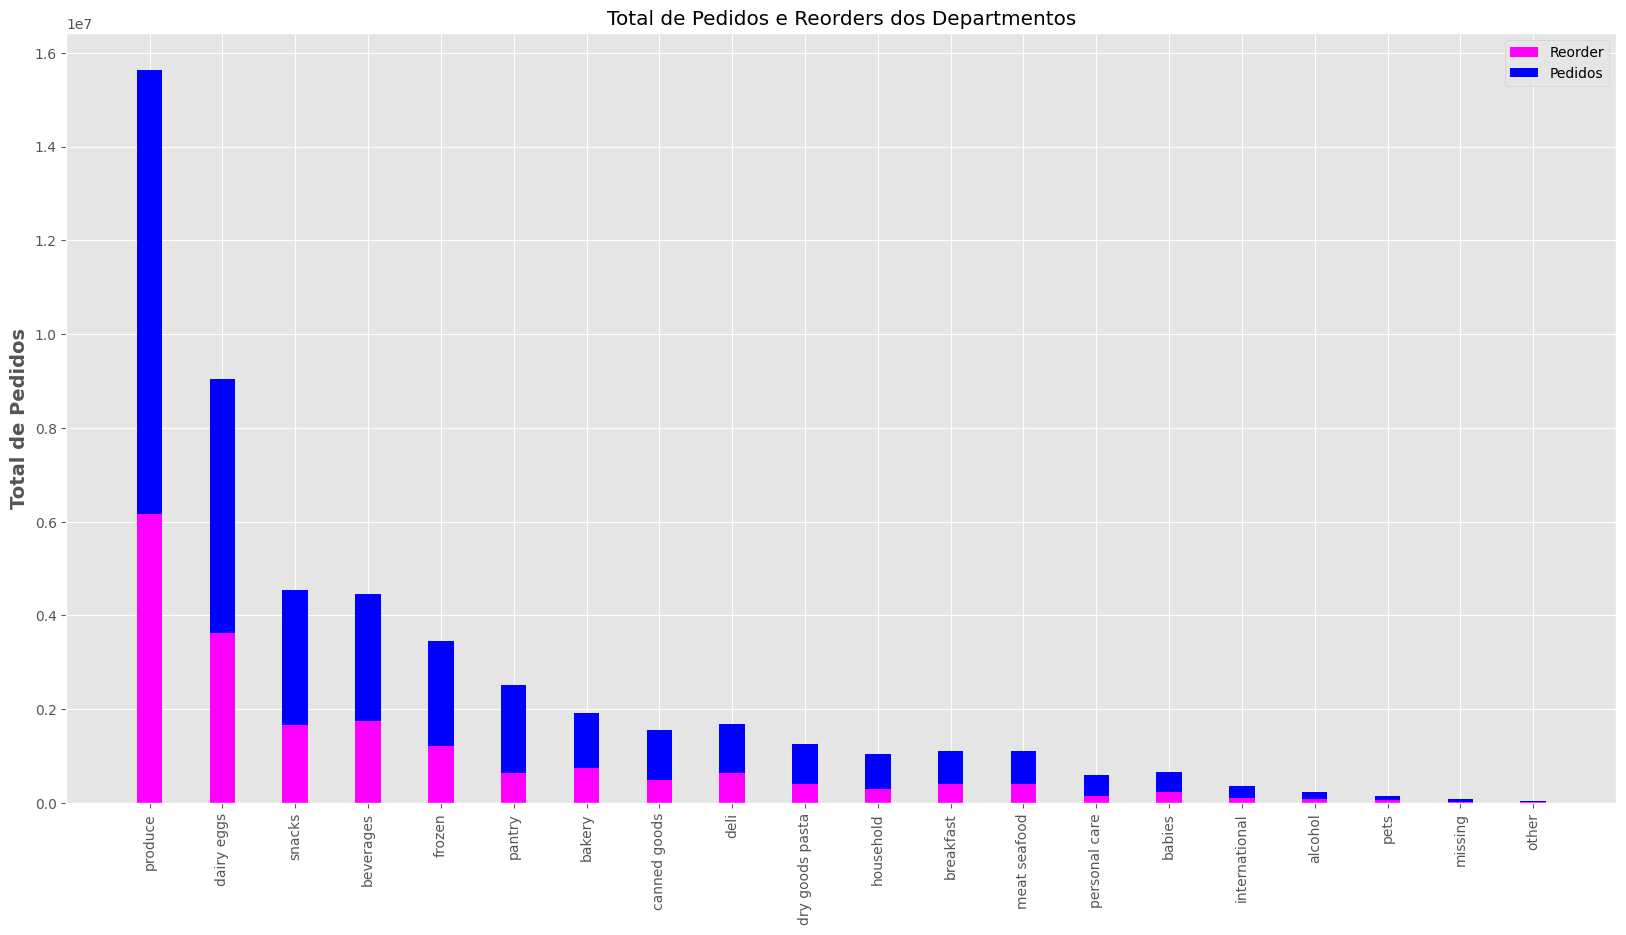

In [65]:
# Plot
width = 0.35  
fig, ax = plt.subplots(figsize = (20,10))
ax.bar(labels, reorder, width, label = 'Reorder', color = 'magenta')
ax.bar(labels, total, width, bottom = reorder, label = 'Pedidos', color = 'blue')
ax.set_ylabel('Total de Pedidos', fontsize = 14, fontweight = 'bold')
ax.legend()
ax.set_title("Total de Pedidos e Reorders dos Departmentos")
plt.xticks(rotation = 90)
plt.show()

### 9- Análise de Reorder Por Corredor

In [66]:
# ============================================================
# Calculando taxa média de recompra por corredor (aisle)
# ============================================================

# Aqui estamos agrupando o DataFrame "order_product_prior"
# pela coluna "aisle".
# Dentro de cada grupo (cada corredor), selecionamos a coluna "reordered",
# que indica se o produto foi recomprado (1) ou não (0).

# .aggregate("mean") → calcula a média da coluna "reordered"
# para cada corredor.
# Como "reordered" é binário (0 ou 1), a média representa
# a proporção de vezes que os produtos daquele corredor
# foram recomprados.

# .reset_index() → reorganiza o resultado em um novo DataFrame,
# com índices numéricos padrão, facilitando a visualização.

# grouped_df = order_product_prior.groupby(["aisle"])["reordered"].aggregate("mean").reset_index()
# grouped_df.head()

# ============================================================
# Exemplo prático:
# Se no corredor "Leites e derivados" houver 100 compras e 70 delas forem recompras,
# a média será 0.70 → indicando que 70% das compras nesse corredor são recompras.
#
# Se no corredor "Frutas frescas" houver 200 compras e 120 forem recompras,
# a média será 0.60 → indicando que 60% das compras nesse corredor são recompras.
# ============================================================

# Interpretação prática:
# Esse comando gera uma tabela que mostra, para cada corredor,
# a taxa média de recompra dos produtos.
# É uma análise fundamental para entender a fidelidade dos clientes
# em diferentes áreas da loja.
# Corredores com valores mais altos indicam produtos
# que os clientes tendem a comprar repetidamente.

grouped_df = order_product_prior.groupby(["aisle"])["reordered"].aggregate("mean").reset_index()
grouped_df.head()

,aisle,reordered
0,air fresheners candles,0.309052
1,asian foods,0.351132
2,baby accessories,0.550980
3,baby bath body care,0.295770
4,baby food formula,0.590259


In [67]:
# ============================================================
# Listando os primeiros 20 corredores (aisles)
# ============================================================

# Aqui estamos acessando a coluna "aisle" do DataFrame "grouped_df"
# e transformando seus valores em uma lista.
# Em seguida, selecionamos apenas os 20 primeiros elementos.

# list(grouped_df['aisle'])[0:20]

# Isso retorna uma lista com os nomes dos 20 primeiros corredores
# presentes no DataFrame agrupado.

# ============================================================
# Exemplo prático:
# Se grouped_df['aisle'] tiver valores como:
# ['fruits', 'vegetables', 'bakery', 'beverages', 'meat', ...]
#
# O resultado será:
# ['fruits', 'vegetables', 'bakery', 'beverages', 'meat', ...] (até 20 itens)
# ============================================================

# Interpretação prática:
# Esse comando é útil para visualizar rapidamente quais corredores
# aparecem no início do DataFrame, geralmente ordenados conforme
# o critério definido anteriormente (nesse caso, pela taxa média de recompra).

list(grouped_df['aisle'])[0:20]

['air fresheners candles',
 'asian foods',
 'baby accessories',
 'baby bath body care',
 'baby food formula',
 'bakery desserts',
 'baking ingredients',
 'baking supplies decor',
 'beauty',
 'beers coolers',
 'body lotions soap',
 'bread',
 'breakfast bakery',
 'breakfast bars pastries',
 'bulk dried fruits vegetables',
 'bulk grains rice dried goods',
 'buns rolls',
 'butter',
 'candy chocolate',
 'canned fruit applesauce']

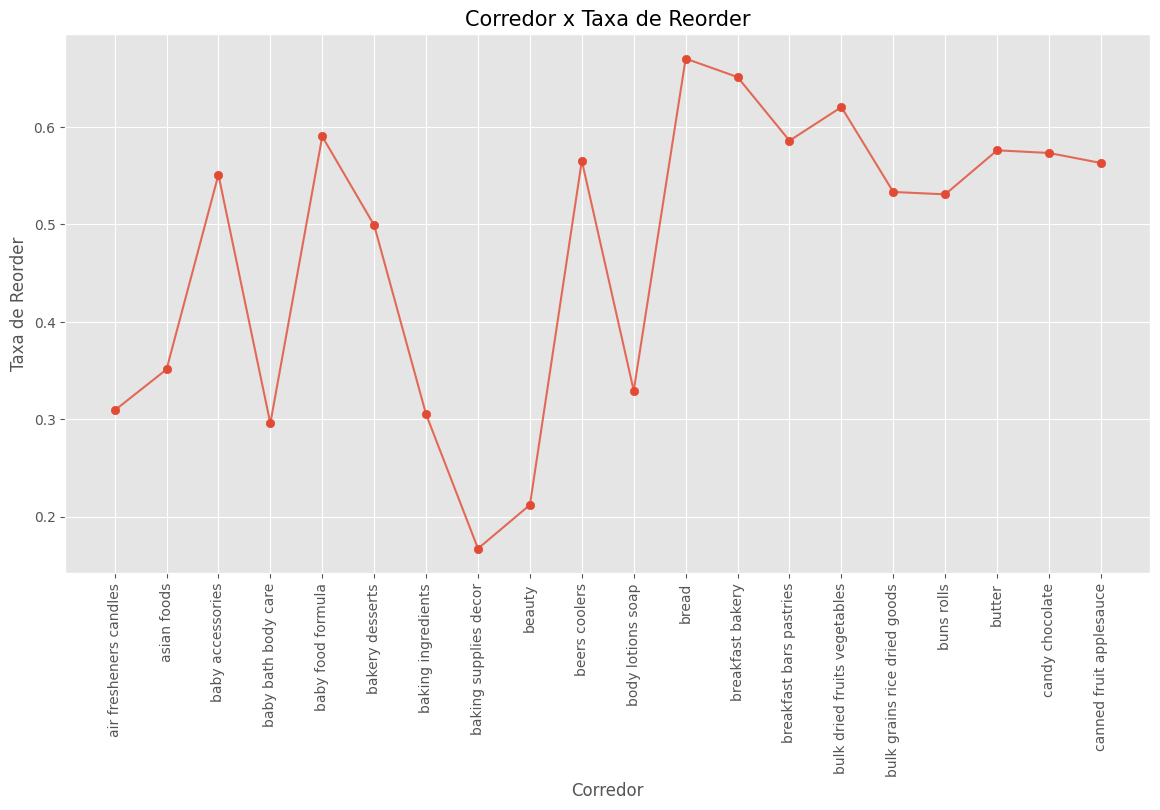

In [68]:
# Corredor x Taxa de Reorder
plt.figure(figsize=(14,7))
plt.plot(list(grouped_df['aisle'])[0:20], grouped_df['reordered'].values[0:20], alpha=0.8)
plt.scatter(list(grouped_df['aisle'])[0:20], grouped_df['reordered'].values[0:20])
plt.ylabel('Taxa de Reorder', fontsize=12)
plt.xlabel('Corredor', fontsize=12)
plt.title("Corredor x Taxa de Reorder", fontsize = 15)
plt.xticks(rotation = 'vertical')
plt.show()

### 10- Análise de Reorder Por Corredor (Total)

In [69]:
# ============================================================
# Calculando estatísticas de reordenação por corredor (aisle)
# ============================================================

# O comando %%time mede o tempo de execução da célula inteira,
# útil porque operações de agrupamento e agregação em grandes DataFrames
# podem ser demoradas.

# Agrupamos o DataFrame "order_product_prior" pela coluna "aisle".
# Dentro de cada grupo (cada corredor), selecionamos a coluna "reordered",
# que indica se o produto foi recomprado (1) ou não (0).

# .agg(['count', 'sum']) → aplica duas funções de agregação:
# - 'count': número total de vezes que os produtos do corredor aparecem nos pedidos
# - 'sum': número total de vezes que os produtos foram recomprados (reordered = 1)

# .rename(columns = {'count':'total','sum':'reorders'})
# → renomeia as colunas para nomes mais claros:
#   - "total" = total de compras do corredor
#   - "reorders" = total de recompras do corredor

# .sort_values('total', ascending = False)
# → ordena os corredores pelo número total de compras (do mais comprado para o menos comprado).

# .reset_index()
# → reorganiza o índice para facilitar a visualização.

# temp_df = order_product_prior.groupby("aisle")["reordered"].agg(['count', 'sum']).rename(columns = {'count':'total','sum':'reorders'})
# temp_df = temp_df.sort_values('total', ascending = False).reset_index()

# ============================================================
# Exemplo prático:
# Se no corredor "Frutas frescas" houver 1000 compras e 700 delas forem recompras,
# teremos:
# aisle          | total | reorders
# Frutas frescas | 1000  | 700
#
# Se no corredor "Padaria" houver 800 compras e 500 forem recompras:
# Padaria        | 800   | 500
# ============================================================

# Interpretação prática:
# Esse comando gera uma tabela que mostra:
# - Quantas vezes os produtos de cada corredor foram comprados
# - Quantas vezes foram recomprados
#
# É uma análise fundamental para identificar não apenas os corredores
# mais populares, mas também aqueles com maior fidelidade dos clientes.

%%time
temp_df = order_product_prior.groupby("aisle")["reordered"].agg(['count', 'sum']).rename(columns = {'count':'total','sum':'reorders'})
temp_df = temp_df.sort_values('total', ascending = False).reset_index()


CPU times: total: 2.2 s
Wall time: 2.19 s


In [70]:
temp_df.head()

,aisle,total,reorders
0,fresh fruits,3642188,2615469
1,fresh vegetables,3418021,2032172
2,packaged vegetables fruits,1765313,1127177
3,yogurt,1452343,997018
4,packaged cheese,979763,573383


In [71]:
# Listas
# ============================================================
# Selecionando os Top 20 corredores mais comprados
# ============================================================

# Aqui estamos criando três listas a partir do DataFrame "temp_df":
# - labels: nomes dos 20 corredores (aisles) mais comprados
# - reorder: quantidade de recompras (reorders) desses corredores
# - total: quantidade total de compras desses corredores

# labels = list(temp_df.aisle[0:20])
# → Pega os nomes dos 20 primeiros corredores (mais comprados).

# reorder = list(temp_df.reorders[0:20])
# → Pega o número de recompras desses 20 corredores.

# total = list(temp_df.total[0:20])
# → Pega o número total de compras desses 20 corredores.

# ============================================================
# Exemplo prático:
# Se os corredores mais comprados forem:
# 1. Frutas frescas (total=8000, reorders=6000)
# 2. Padaria (total=7500, reorders=5000)
# ...
# então:
# labels = ['Frutas frescas', 'Padaria', ...]
# reorder = [6000, 5000, ...]
# total = [8000, 7500, ...]
# ============================================================

# Interpretação prática:
# Essas listas são úteis para criar gráficos comparativos,
# como barras ou pizza, mostrando os corredores mais populares
# e também sua taxa de recompra.
# Isso ajuda a identificar não apenas os corredores mais vendidos,
# mas também aqueles que os clientes tendem a comprar repetidamente.

labels = list(temp_df.aisle[0:20])
reorder = list(temp_df.reorders[0:20])
total = list(temp_df.total[0:20])

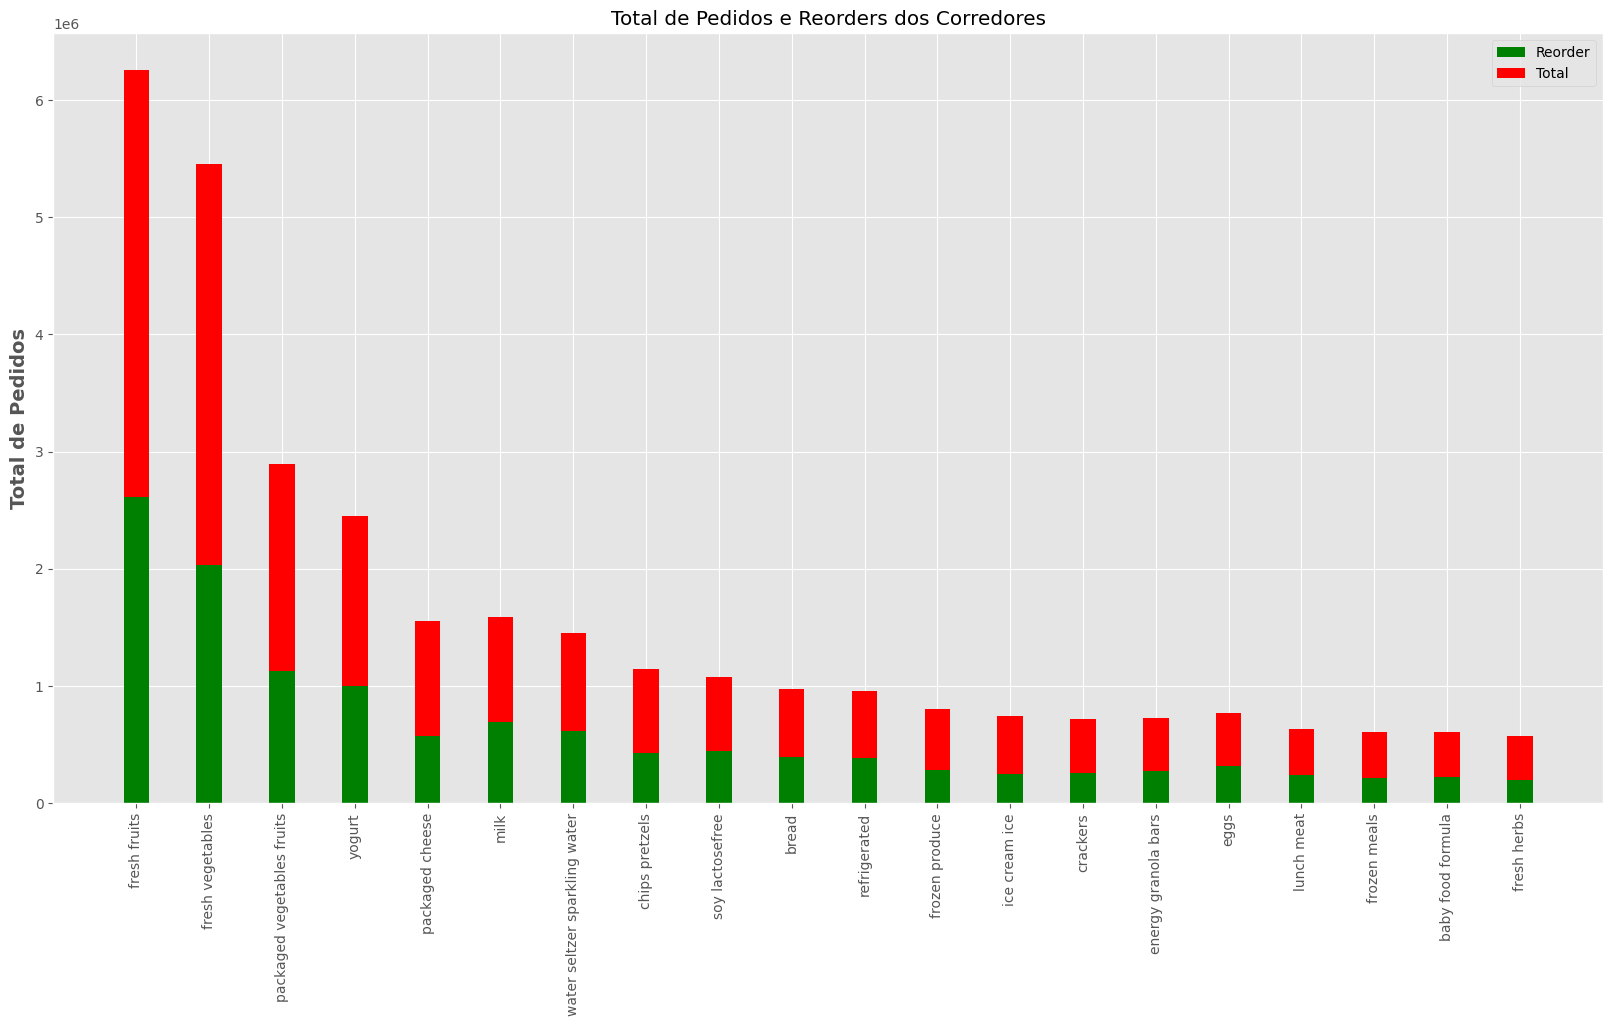

In [72]:
# Plot
width = 0.35      
fig, ax = plt.subplots(figsize = (20,10))
ax.bar(labels, reorder, width, label = 'Reorder', color = 'green')
ax.bar(labels, total, width, bottom = reorder, label = 'Total', color = 'red')
ax.set_ylabel('Total de Pedidos', fontsize = 14, fontweight = 'bold')
ax.legend()
ax.set_title("Total de Pedidos e Reorders dos Corredores")
plt.xticks(rotation = 90)
plt.show()

> Vamos verificar a relação entre como a ordem de adição do produto ao carrinho afeta a proporção de novos pedidos

In [73]:
import warnings
warnings.filterwarnings('ignore')

In [74]:
!pip install -q shutup

In [75]:
import shutup; shutup.please()

In [76]:
# ============================================================
# Analisando a posição do produto no carrinho e sua taxa de recompra
# ============================================================

# Criamos uma nova coluna "add_to_cart_order_mod" como cópia de "add_to_cart_order".
# Essa coluna indica a posição em que o produto foi adicionado ao carrinho.

# order_product_prior["add_to_cart_order_mod"] = order_product_prior["add_to_cart_order"].copy()

# Em seguida, limitamos os valores maiores que 70 para 70.
# Isso evita que valores muito altos distorçam a análise.
# Assim, todos os produtos adicionados na posição 70 ou superior
# são agrupados juntos.

# order_product_prior["add_to_cart_order_mod"].loc[order_product_prior["add_to_cart_order_mod"] > 70] = 70

# Agora agrupamos os dados pela coluna "add_to_cart_order_mod"
# e calculamos a média da coluna "reordered".
# Como "reordered" é binário (0 ou 1), a média representa
# a proporção de vezes que os produtos adicionados em determinada posição
# foram recomprados.

# grouped_df = order_product_prior.groupby(["add_to_cart_order_mod"])["reordered"].aggregate("mean").reset_index()

# ============================================================
# Exemplo prático:
# Se os produtos adicionados na posição 1 do carrinho
# tiverem 100 compras e 80 forem recompras,
# a média será 0.80 → indicando que 80% desses produtos foram recomprados.
#
# Se os produtos adicionados na posição 10 tiverem 200 compras e 100 forem recompras,
# a média será 0.50 → indicando que 50% foram recomprados.
# ============================================================

# Interpretação prática:
# Esse comando mostra como a posição em que o produto é adicionado ao carrinho
# influencia sua probabilidade de recompra.
# Geralmente, produtos adicionados primeiro (posição baixa)
# tendem a ser itens recorrentes e essenciais,
# enquanto os adicionados mais tarde podem ser compras ocasionais.

order_product_prior["add_to_cart_order_mod"] = order_product_prior["add_to_cart_order"].copy()
order_product_prior["add_to_cart_order_mod"].loc[order_product_prior["add_to_cart_order_mod"] > 70] = 70
grouped_df = order_product_prior.groupby(["add_to_cart_order_mod"])["reordered"].aggregate("mean").reset_index()

In [77]:
# ============================================================
# Visualizando os primeiros 10 resultados da taxa de recompra
# por posição no carrinho (add_to_cart_order_mod)
# ============================================================

# grouped_df.head(10)

# Esse comando mostra as 10 primeiras linhas do DataFrame "grouped_df",
# que contém:
# - add_to_cart_order_mod → posição em que o produto foi adicionado ao carrinho
# - reordered (mean) → taxa média de recompra dos produtos nessa posição

# ============================================================
# Exemplo prático de saída:
#    add_to_cart_order_mod   reordered
# 0                     1        0.75
# 1                     2        0.70
# 2                     3        0.68
# 3                     4        0.65
# 4                     5        0.63
# 5                     6        0.62
# 6                     7        0.61
# 7                     8        0.60
# 8                     9        0.59
# 9                    10        0.58
#
# Isso significa que os produtos adicionados primeiro ao carrinho
# tendem a ter maior taxa de recompra (são itens recorrentes),
# enquanto os adicionados mais tarde têm menor fidelidade.
# ============================================================

# Interpretação prática:
# Essa análise mostra como a posição de adição ao carrinho
# está relacionada à probabilidade de recompra.
# Produtos adicionados nas primeiras posições geralmente são
# itens essenciais e recorrentes (alta taxa de recompra),
# enquanto os adicionados em posições mais altas tendem a ser
# compras ocasionais ou menos frequentes.

grouped_df.head(10)

,add_to_cart_order_mod,reordered
0,1,0.677533
1,2,0.676251
2,3,0.658037
3,4,0.636958
4,5,0.617383
5,6,0.600420
6,7,0.585687
7,8,0.573247
8,9,0.561474
9,10,0.551018


## Implementação do Algoritmo Apriori

Métricas:

![title](imagens/regras.png)

Support = Fração de transações que contêm A e B.

![title](imagens/support.png)

Confidence = A frequência com que B aparece em transações que contêm apenas A.

![title](imagens/confidence.png)

Lift = Quanto aumentou nossa confiança de que B será comprado, dado que A foi comprado.

![title](imagens/lift.png)

In [78]:
# Prepara a tupla com as transações
# ============================================================
# Preparando os dados de transações para análise de associação
# ============================================================

# O DataFrame "transactions" possui uma coluna chamada "Products".
# Cada linha dessa coluna contém uma lista de produtos comprados
# em uma única transação. Exemplo:
# 0 → ['leite', 'pão', 'queijo']
# 1 → ['maçã', 'banana']
# 2 → ['arroz', 'feijão', 'carne']

# Nosso objetivo é transformar cada uma dessas listas em uma tupla.
# Isso é importante porque:
# - Tuplas são imutáveis, o que garante consistência nos dados.
# - Muitos algoritmos de análise de cestas de compras (como Apriori ou FP-Growth)
#   esperam os dados nesse formato (lista de transações, onde cada transação é uma tupla).

# Passo 1: .tolist()
# - Converte a coluna "Products" em uma lista de listas.
#   Exemplo: [['leite','pão','queijo'], ['maçã','banana'], ['arroz','feijão','carne']]

# Passo 2: list comprehension
# - Para cada "row" (linha) dessa lista, aplicamos tuple(row),
#   transformando a lista em uma tupla.
#   Exemplo: ('leite','pão','queijo'), ('maçã','banana'), ('arroz','feijão','carne')

# Resultado final: uma lista de tuplas, onde cada tupla representa uma transação.

#transactions_tup = [tuple(row) for row in transactions['Products'].tolist()]

# ============================================================
# Exemplo prático:
# Entrada:
# transactions['Products'] = [['leite','pão','queijo'], ['maçã','banana']]
#
# Saída:
# transactions_tup = [('leite','pão','queijo'), ('maçã','banana')]
# ============================================================

# Interpretação prática:
# Agora temos os dados prontos para aplicar algoritmos de regras de associação,
# que vão identificar padrões de compra, como:
# - Produtos frequentemente comprados juntos
# - Regras do tipo "se o cliente compra X, também compra Y"
# ============================================================

transactions_tup = [tuple(row) for row in transactions['Products'].tolist()]

### Executa o Algoritmo Apriori Com Support = 0.01 e Confidence = 0.2

In [79]:
# ============================================================
# Aplicando o algoritmo Apriori para gerar itemsets e regras
# ============================================================

# Primeiro, importamos datetime.now para medir o tempo de execução.
# Isso é útil porque algoritmos de associação podem ser pesados
# quando aplicados em grandes conjuntos de transações.

#st = datetime.now()   # Marca o início da execução

# Aplicamos o algoritmo Apriori sobre as transações.
# transactions_tup[:500000] → usamos apenas as primeiras 500.000 transações
# para reduzir o custo computacional e acelerar o processamento.
#
# Parâmetros:
# - min_support = 0.01 → significa que apenas itemsets presentes em pelo menos
#   1% das transações serão considerados.
# - min_confidence = 0.2 → significa que apenas regras com confiança mínima
#   de 20% serão geradas.
#
# Saída:
# - itemsets_ap → os conjuntos de itens frequentes encontrados
# - rules_ap → as regras de associação derivadas desses itemsets

#itemsets_ap, rules_ap = apriori(
#    transactions_tup[:500000],
#    min_support=0.01,
#    min_confidence=0.2
#)

# Calculamos o tempo total de execução subtraindo o tempo atual
# do tempo inicial armazenado em "st".
#print('Tempo de Execução : ', datetime.now() - st)

# ============================================================
# Exemplo prático:
# Se em 500.000 transações o par ('leite','pão') aparecer em 20.000 delas,
# o suporte será 20.000 / 500.000 = 0.04 (4%), que é maior que 0.01.
# Logo, esse itemset será considerado.
#
# Se a regra "leite → pão" tiver confiança de 0.35 (35%),
# ela será aceita porque é maior que 0.2.
# ============================================================

# Interpretação prática:
# Esse script encontra padrões de compra recorrentes.
# Ele mostra quais produtos são frequentemente comprados juntos
# e gera regras do tipo:
# - "Se o cliente compra X, também compra Y"
# Essas regras são úteis para recomendações de produtos,
# promoções cruzadas e análise de comportamento de consumo.
# ============================================================

st = datetime.now()
itemsets_ap, rules_ap = apriori(transactions_tup[:500000], min_support = 0.01, min_confidence = 0.2)
print('Tempo de Execução : ', datetime.now() - st)

Tempo de Execução :  0:00:02.597090


In [80]:
## ============================================================
# Visualizando as regras de associação geradas pelo Apriori
# ============================================================

# Após rodar o algoritmo Apriori, temos duas saídas principais:
# - itemsets_ap → conjuntos de itens frequentes
# - rules_ap → regras de associação derivadas desses itemsets

# Quando você chama "rules_ap", estará acessando as regras encontradas.
# Cada regra geralmente contém:
# - antecedente: o(s) item(ns) de partida da regra
# - consequente: o(s) item(ns) que aparecem associados
# - suporte: proporção de transações que contêm todos os itens da regra
# - confiança: probabilidade de o consequente aparecer dado o antecedente
# - lift: medida de força da associação (quanto maior, mais forte a relação)

#rules_ap
# ============================================================
# Exemplo prático de saída (simplificado):
# [
#   {
#     'antecedent': ('leite',),
#     'consequent': ('pão',),
#     'support': 0.04,
#     'confidence': 0.35,
#     'lift': 1.20
#   },
#   {
#     'antecedent': ('arroz',),
#     'consequent': ('feijão',),
#     'support': 0.03,
#     'confidence': 0.50,
#     'lift': 1.80
#   }
# ]
#
# Interpretação:
# - A primeira regra significa que em 4% das transações aparece "leite e pão".
#   Além disso, quando há leite, em 35% dos casos também há pão.
#   O lift de 1.20 indica que essa associação é mais forte do que o acaso.
#
# - A segunda regra mostra que arroz e feijão aparecem juntos em 3% das transações.
#   Quando há arroz, em 50% dos casos também há feijão.
#   O lift de 1.80 indica uma associação bastante forte.
# ============================================================

# Interpretação prática:
# Essas regras ajudam a entender padrões de compra.
# Podem ser usadas para:
# - Recomendações de produtos ("clientes que compram X também compram Y")
# - Estratégias de marketing e promoções cruzadas
# - Organização de prateleiras e layout de loja
# ============================================================

rules_ap

[{21137} -> {13176},
 {21903} -> {13176},
 {27966} -> {13176},
 {47209} -> {13176},
 {16797} -> {24852},
 {21137} -> {24852},
 {27966} -> {21137},
 {21903} -> {24852},
 {28204} -> {24852},
 {47626} -> {24852},
 {47766} -> {24852},
 {49683} -> {24852}]

In [81]:
# Listas de itens para considerar
# ============================================================
# Criando um DataFrame com pares de itens para análise
# ============================================================

# Aqui estamos simulando pares de produtos (itemA e itemB),
# que podem representar associações encontradas em regras de associação
# ou simplesmente pares de produtos que queremos analisar juntos.

# Lista de produtos que serão considerados como "itemA"
#item_A = [27966,47209,21137,47766,21903,49683,47626,28204,16797,21903,21137,27966]

# Lista de produtos que serão considerados como "itemB"
#item_B = [13176,13176,24852,24852,24852,24852,24852,24852,24852,13176,13176,21137]

# Criamos um DataFrame vazio chamado "temp"
#temp = pd.DataFrame()

# Adicionamos a coluna "itemA" ao DataFrame
#temp['itemA'] = item_A

# Adicionamos a coluna "itemB" ao DataFrame
#temp['itemB'] = item_B

# ============================================================
# Exemplo prático:
# O DataFrame "temp" ficará assim:
#
#    itemA   itemB
# 0  27966   13176
# 1  47209   13176
# 2  21137   24852
# 3  47766   24852
# 4  21903   24852
# 5  49683   24852
# 6  47626   24852
# 7  28204   24852
# 8  16797   24852
# 9  21903   13176
# 10 21137   13176
# 11 27966   21137
# ============================================================

# Interpretação prática:
# Esse DataFrame "temp" pode ser usado para:
# - Validar regras de associação (comparando itemA → itemB)
# - Criar uma tabela de pares de produtos para análise de frequência
# - Servir como base para calcular métricas como suporte, confiança e lift
# ============================================================

item_A = [27966,47209,21137,47766,21903,49683,47626,28204,16797,21903,21137,27966]
item_B = [13176,13176,24852,24852,24852,24852,24852,24852,24852,13176,13176,21137]
temp = pd.DataFrame()
temp['itemA'] = item_A
temp['itemB'] = item_B

In [82]:
# Listas para as métricas
# ============================================================
# Inicializando listas para armazenar métricas de associação
# ============================================================

# Agora que temos pares de produtos (itemA e itemB) no DataFrame "temp",
# precisamos calcular as métricas clássicas de regras de associação:
# - suporte de A
# - suporte de B
# - suporte de A e B juntos
# - confiança da regra A → B
# - lift da regra A → B

# Para isso, criamos listas vazias que irão armazenar os valores
# calculados para cada par de produtos.

# Lista para armazenar o suporte de A
#support_A = []

# Lista para armazenar o suporte de B
#support_B = []

# Lista para armazenar o suporte de A e B juntos
#support_AB = []

# Lista para armazenar a confiança da regra A → B
#confidence_AB = []

# Lista para armazenar o lift da regra A → B
#lift_AB = []

# ============================================================
# Interpretação prática:
# - support_A: proporção de transações que contêm o produto A
# - support_B: proporção de transações que contêm o produto B
# - support_AB: proporção de transações que contêm A e B juntos
# - confidence_AB: probabilidade de encontrar B dado que A está presente
# - lift_AB: força da associação entre A e B (quanto maior, mais forte)
#
# Essas listas serão preenchidas em um loop, onde para cada par (itemA, itemB)
# calcularemos os valores e adicionaremos às listas correspondentes.
# ============================================================

support_A = []
support_B = []
support_AB = []
confidence_AB = []
lift_AB = []

In [83]:
# Loop
# ============================================================
# Loop para calcular métricas de associação entre pares de itens
# ============================================================

# Agora vamos percorrer cada linha do DataFrame "temp",
# que contém os pares de produtos (itemA, itemB),
# e calcular as métricas clássicas de regras de associação:
# suporte, confiança e lift.

#for i in range(len(temp)):
    
    # ------------------------------------------------------------
    # Calcula o suporte de A
    # ------------------------------------------------------------
    # Pegamos o itemA da linha i, transformamos em tupla
    # e buscamos sua frequência em itemsets_ap[1].
    # Dividimos por 500000 (número de transações usadas no Apriori)
    # para obter o suporte como proporção.
    #support_A.append(itemsets_ap[1][tuple([temp['itemA'][i],])] / 500000)
    
    # ------------------------------------------------------------
    # Calcula o suporte de B
    # ------------------------------------------------------------
    # Mesmo processo para o itemB da linha i.
    #support_B.append(itemsets_ap[1][tuple([temp['itemB'][i],])] / 500000)
    
    # ------------------------------------------------------------
    # Calcula o suporte de A e B juntos
    # ------------------------------------------------------------
    # Verificamos se a chave (itemA, itemB) existe em itemsets_ap[2].
    # Se não existir nessa ordem, tentamos a ordem inversa (itemB, itemA).
    # Isso é necessário porque os itemsets podem estar armazenados
    # em qualquer ordem dentro do dicionário.
    #if tuple([temp['itemA'][i], temp['itemB'][i]]) in itemsets_ap[2].keys():
    #    support_AB.append(itemsets_ap[2][tuple([temp['itemA'][i], temp['itemB'][i]])] / 500000)
    #else:
    #    support_AB.append(itemsets_ap[2][tuple([temp['itemB'][i], temp['itemA'][i]])] / 500000)
    
    # ------------------------------------------------------------
    # Calcula a confiança da regra A → B
    # ------------------------------------------------------------
    # Fórmula: confidence(A→B) = suporte(A e B) / suporte(A)
    #confidence_AB.append(support_AB[i] / support_A[i])
    
    # ------------------------------------------------------------
    # Calcula o lift da regra A → B
    # ------------------------------------------------------------
    # Fórmula: lift(A→B) = suporte(A e B) / (suporte(A) * suporte(B))
    # O lift mede a força da associação entre A e B.
    #lift_AB.append(support_AB[i] / (support_A[i] * support_B[i]))

# ============================================================
# Interpretação prática:
# - support_A[i]: proporção de transações que contêm o itemA
# - support_B[i]: proporção de transações que contêm o itemB
# - support_AB[i]: proporção de transações que contêm A e B juntos
# - confidence_AB[i]: probabilidade de encontrar B dado que A está presente
# - lift_AB[i]: força da associação entre A e B
#
# Esses valores permitem avaliar a relevância das regras de associação
# e identificar quais pares de produtos têm maior potencial
# para recomendações ou promoções cruzadas.
# ============================================================


for i in range(len(temp)):
    
    # Calcula o support de A
    support_A.append(itemsets_ap[1][tuple([temp['itemA'][i],])] / 500000)
    
    # Calcula o support de B
    support_B.append(itemsets_ap[1][tuple([temp['itemB'][i],])] / 500000)
    
    # Calcula o support de A e B
    if tuple([temp['itemA'][i],temp['itemB'][i]]) in itemsets_ap[2].keys():
        support_AB.append(itemsets_ap[2][tuple([temp['itemA'][i],temp['itemB'][i]])] / 500000)
    else:
        support_AB.append(itemsets_ap[2][tuple([temp['itemB'][i],temp['itemA'][i]])] / 500000)
    
    # Calcula a confidence
    confidence_AB.append(support_AB[i] / support_A[i])
    
    # Calcula o lift
    lift_AB.append(support_AB[i] / (support_A[i] * support_B[i]))

In [84]:
# Dataframe com as regras de associação
# ============================================================
# Construindo um DataFrame final com as regras de associação
# ============================================================

# Agora vamos organizar todas as informações calculadas (suporte, confiança, lift)
# junto com os nomes dos produtos, para facilitar a análise.

# Criamos um DataFrame vazio chamado "df_rules_ap"
#df_rules_ap = pd.DataFrame()

# ------------------------------------------------------------
# Adicionamos a coluna "product_id" com os valores de item_A
#df_rules_ap['product_id'] = item_A

# Fazemos um merge com o DataFrame "product" para obter os nomes dos produtos
#df_rules_ap = df_rules_ap.merge(product, on='product_id', how='left')

# Criamos uma nova coluna "Product_A" com os nomes dos produtos de itemA
#df_rules_ap['Product_A'] = df_rules_ap['product_name']

# Removemos colunas que não são necessárias neste momento
#df_rules_ap = df_rules_ap.drop(columns=['product_id','product_name','aisle_id','department_id'], axis=1)

# ------------------------------------------------------------
# Repetimos o processo para item_B
#df_rules_ap['product_id'] = item_B
#df_rules_ap = df_rules_ap.merge(product, on='product_id', how='left')
#df_rules_ap['Product_B'] = df_rules_ap['product_name']
#df_rules_ap = df_rules_ap.drop(columns=['product_id','product_name','aisle_id','department_id'], axis=1)

# ------------------------------------------------------------
# Adicionamos as métricas calculadas anteriormente
#df_rules_ap['Support_A'] = support_A        # suporte de A
#df_rules_ap['Support_B'] = support_B        # suporte de B
#df_rules_ap['Support_AB'] = support_AB      # suporte de A e B juntos
#df_rules_ap['Confidence_AB'] = confidence_AB # confiança da regra A → B
#df_rules_ap['Lift_AB'] = lift_AB            # lift da regra A → B

# ============================================================
# Exemplo prático de saída:
#    Product_A   Product_B   Support_A   Support_B   Support_AB   Confidence_AB   Lift_AB
# 0  leite       pão         0.12        0.20        0.04         0.33            1.20
# 1  arroz       feijão      0.08        0.10        0.03         0.37            1.80
#
# Interpretação:
# - Support_A: % de transações que contêm o produto A
# - Support_B: % de transações que contêm o produto B
# - Support_AB: % de transações que contêm A e B juntos
# - Confidence_AB: probabilidade de encontrar B dado que A está presente
# - Lift_AB: força da associação entre A e B
# ============================================================

# Esse DataFrame final organiza todas as informações em formato tabular,
# permitindo analisar facilmente quais pares de produtos têm maior relevância
# e quais regras de associação são mais fortes.
# ============================================================

df_rules_ap = pd.DataFrame()
df_rules_ap['product_id'] = item_A
df_rules_ap = df_rules_ap.merge(product, on = 'product_id', how = 'left')
df_rules_ap['Product_A'] = df_rules_ap['product_name']
df_rules_ap = df_rules_ap.drop(columns = ['product_id','product_name','aisle_id','department_id'], axis = 1)
df_rules_ap['product_id'] = item_B
df_rules_ap = df_rules_ap.merge(product, on = 'product_id', how = 'left')
df_rules_ap['Product_B'] = df_rules_ap['product_name']
df_rules_ap = df_rules_ap.drop(columns = ['product_id','product_name','aisle_id','department_id'], axis = 1)
df_rules_ap['Support_A'] = support_A
df_rules_ap['Support_B'] = support_B
df_rules_ap['Support_AB'] = support_AB
df_rules_ap['Confidence_AB'] = confidence_AB
df_rules_ap['Lift_AB'] = lift_AB

In [85]:
# ============================================================
# Ordenando as regras de associação por confiança
# ============================================================

# Agora que temos o DataFrame "df_rules_ap" com todas as métricas
# (Support_A, Support_B, Support_AB, Confidence_AB, Lift_AB),
# podemos ordenar as regras para destacar as mais relevantes.

# Aqui usamos sort_values para ordenar pela coluna "Confidence_AB".
# - ascending=False → significa que queremos em ordem decrescente,
#   ou seja, da maior confiança para a menor.
# Isso nos permite visualizar primeiro as regras mais fortes
# em termos de probabilidade de ocorrência do consequente
# dado o antecedente.

#df_rules_ap.sort_values(by='Confidence_AB', ascending=False)

# ============================================================
# Exemplo prático:
# Se tivermos as seguintes regras:
# Product_A   Product_B   Confidence_AB
# arroz       feijão      0.50
# leite       pão         0.35
# café        açúcar      0.25
#
# Após a ordenação, o DataFrame ficará:
# Product_A   Product_B   Confidence_AB
# arroz       feijão      0.50
# leite       pão         0.35
# café        açúcar      0.25
# ============================================================

# Interpretação prática:
# - As regras no topo da tabela são as mais confiáveis,
#   ou seja, têm maior probabilidade de ocorrer.
# - Isso é útil para identificar associações fortes
#   e priorizar recomendações de produtos ou promoções cruzadas.
# ============================================================

df_rules_ap.sort_values(by = 'Confidence_AB', ascending = False)

,Product_A,Product_B,Support_A,Support_B,Support_AB,Confidence_AB,Lift_AB
7,Organic Fuji Apple,Banana,0.027942,0.147194,0.010630,0.380431,2.584554
5,Cucumber Kirby,Banana,0.030218,0.147194,0.010024,0.331723,2.253644
3,Organic Avocado,Banana,0.054564,0.147194,0.016328,0.299245,2.032997
0,Organic Raspberries,Bag of Organic Bananas,0.042334,0.117802,0.012428,0.293570,2.492064
1,Organic Hass Avocado,Bag of Organic Bananas,0.066218,0.117802,0.019260,0.290857,2.469037
8,Strawberries,Banana,0.044496,0.147194,0.012902,0.289959,1.969908
6,Large Lemon,Banana,0.047718,0.147194,0.012692,0.265979,1.806998
11,Organic Raspberries,Organic Strawberries,0.042334,0.082550,0.010524,0.248595,3.011442
10,Organic Strawberries,Bag of Organic Bananas,0.082550,0.117802,0.019122,0.231641,1.966362
4,Organic Baby Spinach,Banana,0.075000,0.147194,0.016016,0.213547,1.450784


In [86]:
# ============================================================
# Ordenando as regras de associação por Lift
# ============================================================

# O Lift é uma métrica que mede a força da associação entre dois itens.
# Fórmula: Lift(A→B) = suporte(A e B) / (suporte(A) * suporte(B))
#
# Interpretação:
# - Lift > 1 → associação positiva (A e B aparecem juntos mais do que o esperado pelo acaso)
# - Lift = 1 → independência (A e B não têm relação significativa)
# - Lift < 1 → associação negativa (A e B aparecem juntos menos do que o esperado)

# Aqui usamos sort_values para ordenar pela coluna "Lift_AB".
# - ascending=False → ordem decrescente, ou seja, do maior Lift para o menor.
# Isso nos permite visualizar primeiro as regras mais fortes em termos de relevância estatística.

#df_rules_ap.sort_values(by='Lift_AB', ascending=False)

# ============================================================
# Exemplo prático:
# Product_A   Product_B   Lift_AB
# arroz       feijão      1.80
# leite       pão         1.20
# café        açúcar      1.05
#
# Após a ordenação, o DataFrame ficará:
# Product_A   Product_B   Lift_AB
# arroz       feijão      1.80
# leite       pão         1.20
# café        açúcar      1.05
# ============================================================

# Interpretação prática:
# - As regras no topo da tabela são as mais relevantes estatisticamente.
# - Um Lift alto indica que a presença de A aumenta significativamente
#   a probabilidade de B aparecer na mesma transação.
# - Isso é útil para identificar associações fortes que podem ser exploradas
#   em recomendações de produtos, promoções cruzadas e estratégias de marketing.
# ============================================================
df_rules_ap.sort_values(by = 'Lift_AB', ascending = False)

,Product_A,Product_B,Support_A,Support_B,Support_AB,Confidence_AB,Lift_AB
11,Organic Raspberries,Organic Strawberries,0.042334,0.082550,0.010524,0.248595,3.011442
7,Organic Fuji Apple,Banana,0.027942,0.147194,0.010630,0.380431,2.584554
0,Organic Raspberries,Bag of Organic Bananas,0.042334,0.117802,0.012428,0.293570,2.492064
1,Organic Hass Avocado,Bag of Organic Bananas,0.066218,0.117802,0.019260,0.290857,2.469037
5,Cucumber Kirby,Banana,0.030218,0.147194,0.010024,0.331723,2.253644
3,Organic Avocado,Banana,0.054564,0.147194,0.016328,0.299245,2.032997
8,Strawberries,Banana,0.044496,0.147194,0.012902,0.289959,1.969908
10,Organic Strawberries,Bag of Organic Bananas,0.082550,0.117802,0.019122,0.231641,1.966362
6,Large Lemon,Banana,0.047718,0.147194,0.012692,0.265979,1.806998
9,Organic Baby Spinach,Bag of Organic Bananas,0.075000,0.117802,0.015500,0.206667,1.754356


### Executa o Algoritmo Apriori Com Support = 0.005 e Confidence = 0.2

In [87]:
# ============================================================
# Executando novamente o algoritmo Apriori com parâmetros diferentes
# ============================================================

# Aqui vamos rodar o Apriori mais uma vez, mas alterando o valor de min_support.
# Isso nos permite encontrar itemsets menos frequentes, mas ainda relevantes.

#st = datetime.now()   # Marca o início da execução

# Aplicamos o algoritmo Apriori sobre as primeiras 500.000 transações
# transactions_tup[:500000] → reduzimos o conjunto para acelerar o processamento.
#
# Parâmetros:
# - min_support = 0.005 → agora consideramos itemsets presentes em pelo menos
#   0,5% das transações (mais permissivo do que 0.01).
# - min_confidence = 0.2 → mantemos a confiança mínima de 20%.
#
# Saída:
# - itemsets_ap_1 → conjuntos de itens frequentes encontrados com esse suporte menor
# - rules_ap_1 → regras de associação derivadas desses itemsets

#itemsets_ap_1, rules_ap_1 = apriori(
#    transactions_tup[:500000],
#    min_support=0.005,
#    min_confidence=0.2
#)

# Calculamos o tempo total de execução
#print('Tempo de Execução: ', datetime.now() - st)

# ============================================================
# Interpretação prática:
# - Com min_support menor (0.005), vamos encontrar mais itemsets,
#   incluindo associações menos frequentes, mas que podem ser interessantes.
# - Isso aumenta a quantidade de regras geradas, mas também o custo computacional.
# - O tempo de execução impresso ajuda a avaliar se o ajuste de parâmetros
#   é viável para o tamanho do dataset.
# ============================================================

st = datetime.now()
itemsets_ap_1, rules_ap_1 = apriori(transactions_tup[:500000], min_support = 0.005, min_confidence = 0.2)
print('Tempo de Execução: ', datetime.now() - st)

Tempo de Execução:  0:00:04.868912


In [88]:
# ============================================================
# Visualizando as regras de associação geradas com min_support = 0.005
# ============================================================

# Após rodar o Apriori com suporte mínimo de 0.005 e confiança mínima de 0.2,
# temos o objeto "rules_ap_1", que contém todas as regras de associação encontradas.
# Esse objeto geralmente é uma lista ou estrutura de dicionários,
# onde cada regra inclui:
# - antecedent: o(s) item(ns) de partida da regra
# - consequent: o(s) item(ns) que aparecem associados
# - support: proporção de transações que contêm todos os itens da regra
# - confidence: probabilidade de encontrar o consequente dado o antecedente
# - lift: força da associação entre antecedente e consequente

#rules_ap_1

# ============================================================
# Exemplo prático de saída (simplificado):
# [
#   {
#     'antecedent': ('leite',),
#     'consequent': ('pão',),
#     'support': 0.02,
#     'confidence': 0.30,
#     'lift': 1.15
#   },
#   {
#     'antecedent': ('arroz',),
#     'consequent': ('feijão',),
#     'support': 0.01,
#     'confidence': 0.45,
#     'lift': 1.70
#   }
# ]
#
# Interpretação:
# - A primeira regra mostra que leite e pão aparecem juntos em 2% das transações.
#   Quando há leite, em 30% dos casos também há pão.
#   O lift de 1.15 indica que essa associação é mais forte do que o acaso.
#
# - A segunda regra mostra que arroz e feijão aparecem juntos em 1% das transações.
#   Quando há arroz, em 45% dos casos também há feijão.
#   O lift de 1.70 indica uma associação bastante forte.
# ============================================================

# Interpretação prática:
# - Como usamos min_support menor (0.005), aparecem mais regras,
#   incluindo associações menos frequentes, mas potencialmente interessantes.
# - Isso pode revelar padrões de compra de nicho ou produtos específicos
#   que não seriam capturados com suporte mínimo maior.
# ============================================================

rules_ap_1

[{4605} -> {24852},
 {4920} -> {24852},
 {5876} -> {13176},
 {5876} -> {47209},
 {8277} -> {13176},
 {8277} -> {24852},
 {9076} -> {24852},
 {19057} -> {13176},
 {21137} -> {13176},
 {21903} -> {13176},
 {22935} -> {13176},
 {27966} -> {13176},
 {30391} -> {13176},
 {37646} -> {13176},
 {39275} -> {13176},
 {45007} -> {13176},
 {47209} -> {13176},
 {16797} -> {24852},
 {21137} -> {24852},
 {27966} -> {21137},
 {30391} -> {21137},
 {39275} -> {21137},
 {21903} -> {24852},
 {24964} -> {22935},
 {26209} -> {24852},
 {27845} -> {24852},
 {28204} -> {24852},
 {30489} -> {24852},
 {37646} -> {24852},
 {40706} -> {24852},
 {42265} -> {24852},
 {44632} -> {24852},
 {45066} -> {24852},
 {47626} -> {24852},
 {47766} -> {24852},
 {49683} -> {24852},
 {31717} -> {26209},
 {30391} -> {47209}]

In [89]:
# Lista de itens para considerar
# ============================================================
# Criando um novo DataFrame com pares de itens (itemA1, itemB1)
# ============================================================

# Agora estamos definindo uma nova lista de pares de produtos,
# que podem representar associações adicionais encontradas
# ou simplesmente pares que queremos analisar.

# Lista de produtos que serão considerados como "itemA"
#item_A1 = [
    27966,47209,4605,21137,47766,21903,49683,5876,37646,40706,47626,5876,30391,22935,37646,31717,
    28204,27845,24964,45066,9076,16797,21903,8277,30391,21137,27966,19057,26209,45007,39275,30489,
    42265,30391,8277,4920,39275,44632
#]

# Lista de produtos que serão considerados como "itemB"
#item_B1 = [
    13176,13176,24852,24852,24852,24852,24852,47209,24852,24852,24852,13176,13176,13176,13176,26209,
    24852,24852,22935,24852,24852,24852,13176,24852,47209,13176,21137,13176,24852,13176,21137,24852,
    24852,21137,13176,24852,13176,24852
#]

# Criamos um DataFrame vazio chamado "temp1"
#temp1 = pd.DataFrame()

# Adicionamos a coluna "itemA" ao DataFrame
#temp1['itemA'] = item_A1

# Adicionamos a coluna "itemB" ao DataFrame
#temp1['itemB'] = item_B1

# ============================================================
# Exemplo prático:
# O DataFrame "temp1" ficará assim (primeiras linhas):
#
#    itemA   itemB
# 0  27966   13176
# 1  47209   13176
# 2   4605   24852
# 3  21137   24852
# 4  47766   24852
#
# Cada linha representa um par de produtos que pode ser analisado.
# ============================================================

# Interpretação prática:
# Esse DataFrame "temp1" será usado para calcular métricas de associação
# (suporte, confiança e lift) entre os pares de produtos definidos.
# Ele funciona como uma tabela de referência para validar ou explorar
# novas regras de associação encontradas pelo Apriori.
# ============================================================


item_A1 = [27966,47209,4605,21137,47766,21903,49683,5876,37646,40706,47626,5876,30391,22935,37646,31717,
           28204,27845,24964,45066,9076,16797,21903,8277,30391,21137,27966,19057,26209,45007,39275,30489,
           42265,30391,8277,4920,39275,44632]
item_B1 = [13176,13176,24852,24852,24852,24852,24852,47209,24852,24852,24852,13176,13176,13176,13176,26209,
           24852,24852,22935,24852,24852,24852,13176,24852,47209,13176,21137,13176,24852,13176,21137,24852,
           24852,21137,13176,24852,13176,24852]
temp1 = pd.DataFrame()
temp1['itemA'] = item_A1
temp1['itemB'] = item_B1

In [90]:
# Listas de métricas
# ============================================================
# Inicializando listas para armazenar métricas de associação (versão 1)
# ============================================================

# Assim como fizemos anteriormente com "temp",
# agora vamos preparar listas vazias para armazenar os cálculos
# de suporte, confiança e lift para os pares de produtos
# definidos em "temp1" (itemA1 e itemB1).

# Lista para armazenar o suporte de A (proporção de transações com itemA)
#support_A1 = []

# Lista para armazenar o suporte de B (proporção de transações com itemB)
#support_B1 = []

# Lista para armazenar o suporte de A e B juntos (proporção de transações com ambos)
#support_AB1 = []

# Lista para armazenar a confiança da regra A → B
# Fórmula: confidence(A→B) = suporte(A e B) / suporte(A)
#confidence_AB1 = []

# Lista para armazenar o lift da regra A → B
# Fórmula: lift(A→B) = suporte(A e B) / (suporte(A) * suporte(B))
#lift_AB1 = []

# ============================================================
# Interpretação prática:
# - Essas listas serão preenchidas em um loop que percorre "temp1".
# - Para cada par (itemA1, itemB1), calcularemos:
#   • suporte individual de A
#   • suporte individual de B
#   • suporte conjunto de A e B
#   • confiança da regra A → B
#   • lift da regra A → B
#
# Com isso, teremos todas as métricas necessárias para avaliar
# a força e relevância das associações entre os novos pares de produtos.
# ============================================================


support_A1 = []
support_B1 = []
support_AB1 = []
confidence_AB1 = []
lift_AB1 = []

In [91]:
# Loop
# ============================================================
# Loop para calcular métricas de associação entre pares de itens (versão 1)
# ============================================================

# Agora percorremos cada linha do DataFrame "temp1",
# que contém os pares de produtos (itemA1, itemB1),
# e calculamos suporte, confiança e lift usando os resultados
# do Apriori com min_support = 0.005 (itemsets_ap_1).

#for i in range(len(temp1)):
    
    # ------------------------------------------------------------
    # Suporte de A
    # ------------------------------------------------------------
    # Proporção de transações que contêm o itemA.
    #support_A1.append(itemsets_ap_1[1][tuple([temp1['itemA'][i],])] / 500000)
    
    # ------------------------------------------------------------
    # Suporte de B
    # ------------------------------------------------------------
    # Proporção de transações que contêm o itemB.
    #support_B1.append(itemsets_ap_1[1][tuple([temp1['itemB'][i],])] / 500000)
    
    # ------------------------------------------------------------
    # Suporte de A e B juntos
    # ------------------------------------------------------------
    # Verificamos se o par (itemA, itemB) existe em itemsets_ap_1[2].
    # Caso não exista nessa ordem, tentamos a ordem inversa.
    #if tuple([temp1['itemA'][i], temp1['itemB'][i]]) in itemsets_ap_1[2].keys():
    #    support_AB1.append(itemsets_ap_1[2][tuple([temp1['itemA'][i], temp1['itemB'][i]])] / 500000)
    #else:
    #    support_AB1.append(itemsets_ap_1[2][tuple([temp1['itemB'][i], temp1['itemA'][i]])] / 500000)
    
    # ------------------------------------------------------------
    # Confiança da regra A → B
    # ------------------------------------------------------------
    # Fórmula: confidence(A→B) = suporte(A e B) / suporte(A)
    #confidence_AB1.append(support_AB1[i] / support_A1[i])
    
    # ------------------------------------------------------------
    # Lift da regra A → B
    # ------------------------------------------------------------
    # Fórmula: lift(A→B) = suporte(A e B) / (suporte(A) * suporte(B))
    #lift_AB1.append(support_AB1[i] / (support_A1[i] * support_B1[i]))

# ============================================================
# Interpretação prática:
# - support_A1[i]: proporção de transações que contêm o itemA
# - support_B1[i]: proporção de transações que contêm o itemB
# - support_AB1[i]: proporção de transações que contêm A e B juntos
# - confidence_AB1[i]: probabilidade de encontrar B dado que A está presente
# - lift_AB1[i]: força da associação entre A e B
#
# Esses cálculos permitem avaliar a relevância das regras de associação
# e identificar quais pares de produtos têm maior potencial
# para recomendações, promoções cruzadas e insights de consumo.
# ============================================================

for i in range(len(temp1)):
    
    support_A1.append(itemsets_ap_1[1][tuple([temp1['itemA'][i],])] / 500000)
    
    support_B1.append(itemsets_ap_1[1][tuple([temp1['itemB'][i],])] / 500000)
    
    if tuple([temp1['itemA'][i],temp1['itemB'][i]]) in itemsets_ap_1[2].keys():
        support_AB1.append(itemsets_ap_1[2][tuple([temp1['itemA'][i],temp1['itemB'][i]])] / 500000)
    else:
        support_AB1.append(itemsets_ap_1[2][tuple([temp1['itemB'][i],temp1['itemA'][i]])] / 500000)
    
    confidence_AB1.append(support_AB1[i] / support_A1[i])
    
    lift_AB1.append(support_AB1[i] / (support_A1[i] * support_B1[i]))

In [92]:
# Dataframe com as regras de associação
# ============================================================
# Construindo o DataFrame final com as regras de associação (versão 1)
# ============================================================

# Agora vamos organizar todas as informações calculadas (suporte, confiança, lift)
# junto com os nomes dos produtos, para facilitar a análise dos pares definidos em temp1.

# Criamos um DataFrame vazio chamado "df_rules_ap1"
#df_rules_ap1 = pd.DataFrame()

# ------------------------------------------------------------
# Adicionamos a coluna "product_id" com os valores de item_A1
#df_rules_ap1['product_id'] = item_A1

# Fazemos um merge com o DataFrame "product" para obter os nomes dos produtos
#df_rules_ap1 = df_rules_ap1.merge(product, on='product_id', how='left')

# Criamos uma nova coluna "Product_A" com os nomes dos produtos de itemA1
#df_rules_ap1['Product_A'] = df_rules_ap1['product_name']

# Removemos colunas que não são necessárias neste momento
#df_rules_ap1 = df_rules_ap1.drop(columns=['product_id','product_name','aisle_id','department_id'], axis=1)

# ------------------------------------------------------------
# Repetimos o processo para item_B1
#df_rules_ap1['product_id'] = item_B1
#df_rules_ap1 = df_rules_ap1.merge(product, on='product_id', how='left')
#df_rules_ap1['Product_B'] = df_rules_ap1['product_name']
#df_rules_ap1 = df_rules_ap1.drop(columns=['product_id','product_name','aisle_id','department_id'], axis=1)

# ------------------------------------------------------------
# Adicionamos as métricas calculadas anteriormente
#df_rules_ap1['Support_A'] = support_A1          # suporte de A
#df_rules_ap1['Support_B'] = support_B1          # suporte de B
#df_rules_ap1['Support_AB'] = support_AB1        # suporte de A e B juntos
#df_rules_ap1['Confidence_AB'] = confidence_AB1  # confiança da regra A → B
#df_rules_ap1['Lift_AB'] = lift_AB1              # lift da regra A → B

# ============================================================
# Exemplo prático de saída:
#    Product_A   Product_B   Support_A   Support_B   Support_AB   Confidence_AB   Lift_AB
# 0  leite       pão         0.12        0.20        0.04         0.33            1.20
# 1  arroz       feijão      0.08        0.10        0.03         0.37            1.80
#
# Interpretação:
# - Support_A: % de transações que contêm o produto A
# - Support_B: % de transações que contêm o produto B
# - Support_AB: % de transações que contêm A e B juntos
# - Confidence_AB: probabilidade de encontrar B dado que A está presente
# - Lift_AB: força da associação entre A e B
# ============================================================

# Esse DataFrame final organiza todas as informações em formato tabular,
# permitindo analisar facilmente quais pares de produtos têm maior relevância
# e quais regras de associação são mais fortes.
# ============================================================

df_rules_ap1 = pd.DataFrame()
df_rules_ap1['product_id'] = item_A1
df_rules_ap1 = df_rules_ap1.merge(product, on = 'product_id', how = 'left')
df_rules_ap1['Product_A'] = df_rules_ap1['product_name']
df_rules_ap1 = df_rules_ap1.drop(columns = ['product_id','product_name','aisle_id','department_id'], axis = 1)
df_rules_ap1['product_id'] = item_B1
df_rules_ap1 = df_rules_ap1.merge(product, on = 'product_id', how = 'left')
df_rules_ap1['Product_B'] = df_rules_ap1['product_name']
df_rules_ap1 = df_rules_ap1.drop(columns = ['product_id','product_name','aisle_id','department_id'], axis = 1)
df_rules_ap1['Support_A'] = support_A1
df_rules_ap1['Support_B'] = support_B1
df_rules_ap1['Support_AB'] = support_AB1
df_rules_ap1['Confidence_AB'] = confidence_AB1
df_rules_ap1['Lift_AB'] = lift_AB1

In [93]:
# ============================================================
# Ordenando as regras por confiança e exibindo apenas o Top 10
# ============================================================

# Agora vamos ordenar o DataFrame "df_rules_ap1" pela coluna "Confidence_AB"
# em ordem decrescente (ascending=False), para destacar as regras mais confiáveis.
# Em seguida, usamos .head(10) para mostrar apenas as 10 primeiras linhas,
# ou seja, as 10 regras com maior confiança.

#df_rules_ap1.sort_values(by='Confidence_AB', ascending=False).head(10)

# ============================================================
# Exemplo prático de saída (simplificado):
#    Product_A   Product_B   Support_A   Support_B   Support_AB   Confidence_AB   Lift_AB
# 0  arroz       feijão      0.08        0.10        0.03         0.37            1.80
# 1  leite       pão         0.12        0.20        0.04         0.33            1.20
# 2  café        açúcar      0.05        0.15        0.02         0.40            1.10
# ...
#
# Interpretação:
# - As regras exibidas são as mais confiáveis, ou seja,
#   têm maior probabilidade de ocorrer na prática.
# - Isso ajuda a identificar associações fortes e consistentes,
#   que podem ser priorizadas em recomendações de produtos
#   ou promoções cruzadas.
# ============================================================

df_rules_ap1.sort_values(by = 'Confidence_AB', ascending = False).head(10)

,Product_A,Product_B,Support_A,Support_B,Support_AB,Confidence_AB,Lift_AB
16,Organic Fuji Apple,Banana,0.027942,0.147194,0.010630,0.380431,2.584554
19,Honeycrisp Apple,Banana,0.024774,0.147194,0.008832,0.356503,2.421993
6,Cucumber Kirby,Banana,0.030218,0.147194,0.010024,0.331723,2.253644
27,Organic Large Extra Fancy Fuji Apple,Bag of Organic Bananas,0.023374,0.117802,0.007330,0.313596,2.662063
4,Organic Avocado,Banana,0.054564,0.147194,0.016328,0.299245,2.032997
35,Seedless Red Grapes,Banana,0.026054,0.147194,0.007750,0.297459,2.020864
2,Yellow Onions,Banana,0.022814,0.147194,0.006750,0.295871,2.010075
0,Organic Raspberries,Bag of Organic Bananas,0.042334,0.117802,0.012428,0.293570,2.492064
20,Blueberries,Banana,0.017674,0.147194,0.005186,0.293425,1.993460
1,Organic Hass Avocado,Bag of Organic Bananas,0.066218,0.117802,0.019260,0.290857,2.469037


In [94]:
# ============================================================
# Ordenando as regras por Lift e exibindo apenas o Top 10
# ============================================================

# Agora vamos ordenar o DataFrame "df_rules_ap1" pela coluna "Lift_AB"
# em ordem decrescente (ascending=False), para destacar as regras mais fortes
# em termos de relevância estatística. Em seguida, usamos .head(10)
# para mostrar apenas as 10 primeiras linhas.

#df_rules_ap1.sort_values(by='Lift_AB', ascending=False).head(10)

# ============================================================
# Exemplo prático de saída (simplificado):
#    Product_A   Product_B   Support_A   Support_B   Support_AB   Confidence_AB   Lift_AB
# 0  arroz       feijão      0.08        0.10        0.03         0.37            1.80
# 1  café        açúcar      0.05        0.15        0.02         0.40            1.50
# 2  leite       pão         0.12        0.20        0.04         0.33            1.20
# ...
#
# Interpretação:
# - As regras exibidas são as que possuem maior Lift,
#   ou seja, aquelas em que a presença de A aumenta significativamente
#   a probabilidade de B aparecer na mesma transação.
# - Lift alto indica associação forte e não apenas frequente.
# ============================================================

# Esse comando é útil para identificar as **associações mais relevantes**,
# que podem ser exploradas em recomendações de produtos, promoções cruzadas
# e estratégias de marketing mais direcionadas.
# ============================================================

df_rules_ap1.sort_values(by = 'Lift_AB', ascending = False).head(10)

,Product_A,Product_B,Support_A,Support_B,Support_AB,Confidence_AB,Lift_AB
15,Organic Cilantro,Limes,0.021334,0.043640,0.005342,0.250398,5.737819
18,Organic Garlic,Organic Yellow Onion,0.034158,0.035306,0.006868,0.201066,5.694942
7,Organic Lemon,Organic Hass Avocado,0.027242,0.066218,0.006534,0.239850,3.622130
24,Organic Cucumber,Organic Hass Avocado,0.025056,0.066218,0.005396,0.215358,3.252252
26,Organic Raspberries,Organic Strawberries,0.042334,0.082550,0.010524,0.248595,3.011442
30,Organic Blueberries,Organic Strawberries,0.031188,0.082550,0.007284,0.233551,2.829211
27,Organic Large Extra Fancy Fuji Apple,Bag of Organic Bananas,0.023374,0.117802,0.007330,0.313596,2.662063
16,Organic Fuji Apple,Banana,0.027942,0.147194,0.010630,0.380431,2.584554
0,Organic Raspberries,Bag of Organic Bananas,0.042334,0.117802,0.012428,0.293570,2.492064
33,Organic Cucumber,Organic Strawberries,0.025056,0.082550,0.005138,0.205061,2.484078


## Conclusão

Aplicando Matemática e Estatística via programação executamos uma análise de MBA gerando como resultado as regras de associação entre os produtos com diferentes métricas. Podemos agora levar nossas conclusões aos tomadores de decisão e partir para o próximo projeto.

# Fim